In [2]:
import os
import warnings
import gc
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
import IPython.display as ipd

from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'grid.alpha': 0.3,
})

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [5]:
# =============================================================================
# Data Loading
# =============================================================================
PROJECT_ROOT = Path.cwd().resolve()
BASE_PATH = PROJECT_ROOT / "kaggle/input/competitions/birdclef-2026"
TRAIN_CSV = BASE_PATH / "train.csv"
AUDIO_DIR = BASE_PATH / "train_audio"

# Specify dtypes upfront to reduce memory usage
dtype_spec = {
    'filename': 'str',
    'primary_label': 'category',
    'secondary_labels': 'str',
    'author': 'category',
    'license': 'category',
    'rating': 'float32',
    'type': 'category',
}

df = pd.read_csv(TRAIN_CSV, dtype=dtype_spec)

mem_usage = df.memory_usage(deep=True).sum() / 1024 ** 2

print(f"📊 Dataset shape: {df.shape}")
print(f"💾 Memory usage: {mem_usage:.2f} MB")
print(f"🐦 Unique species: {df['primary_label'].nunique()}")
print(f"📁 Columns: {list(df.columns)}")
df.head()

📊 Dataset shape: (35549, 15)
💾 Memory usage: 19.07 MB
🐦 Unique species: 206
📁 Columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


In [8]:
# =============================================================================
# Data Quality Check function - train.csv
# =============================================================================
def data_quality_report(dataframe):
    """Generate a concise data quality report."""
    report = pd.DataFrame({
        'dtype': dataframe.dtypes,
        'non_null': dataframe.isnull().sum(),
        'null_count': dataframe.isnull().sum(),
        'null_pct': (dataframe.isnull().sum() / len(dataframe) * 100).round(2),
        'n_unique': dataframe.nunique(),
        'sample_value': dataframe.iloc[0]
    })
    return report


quality = data_quality_report(df)
print("📋 Data Quality Report:")
display(quality)

📋 Data Quality Report:


,dtype,non_null,null_count,null_pct,n_unique,sample_value
primary_label,category,0,0,0.0,206,1161364
secondary_labels,object,0,0,0.0,1517,[]
type,category,0,0,0.0,755,[]
latitude,float64,0,0,0.0,15270,-22.7562
longitude,float64,0,0,0.0,15265,-46.8666
scientific_name,object,0,0,0.0,206,Guyalna cuta
common_name,object,0,0,0.0,206,Guyalna cuta
class_name,object,0,0,0.0,5,Insecta
inat_taxon_id,int64,0,0,0.0,206,1161364
author,category,0,0,0.0,4017,Lucas Barbosa



 Species Distribution Summary:
     Total species: 206
     Max recordings: 499 (rubthr1
     Min recordings: 1 (516975
     Mean: 172.6 | Median 125.0
     Std 155.4
     Species with < 10 recordings: 25
     Species with < 5 recordings: 14


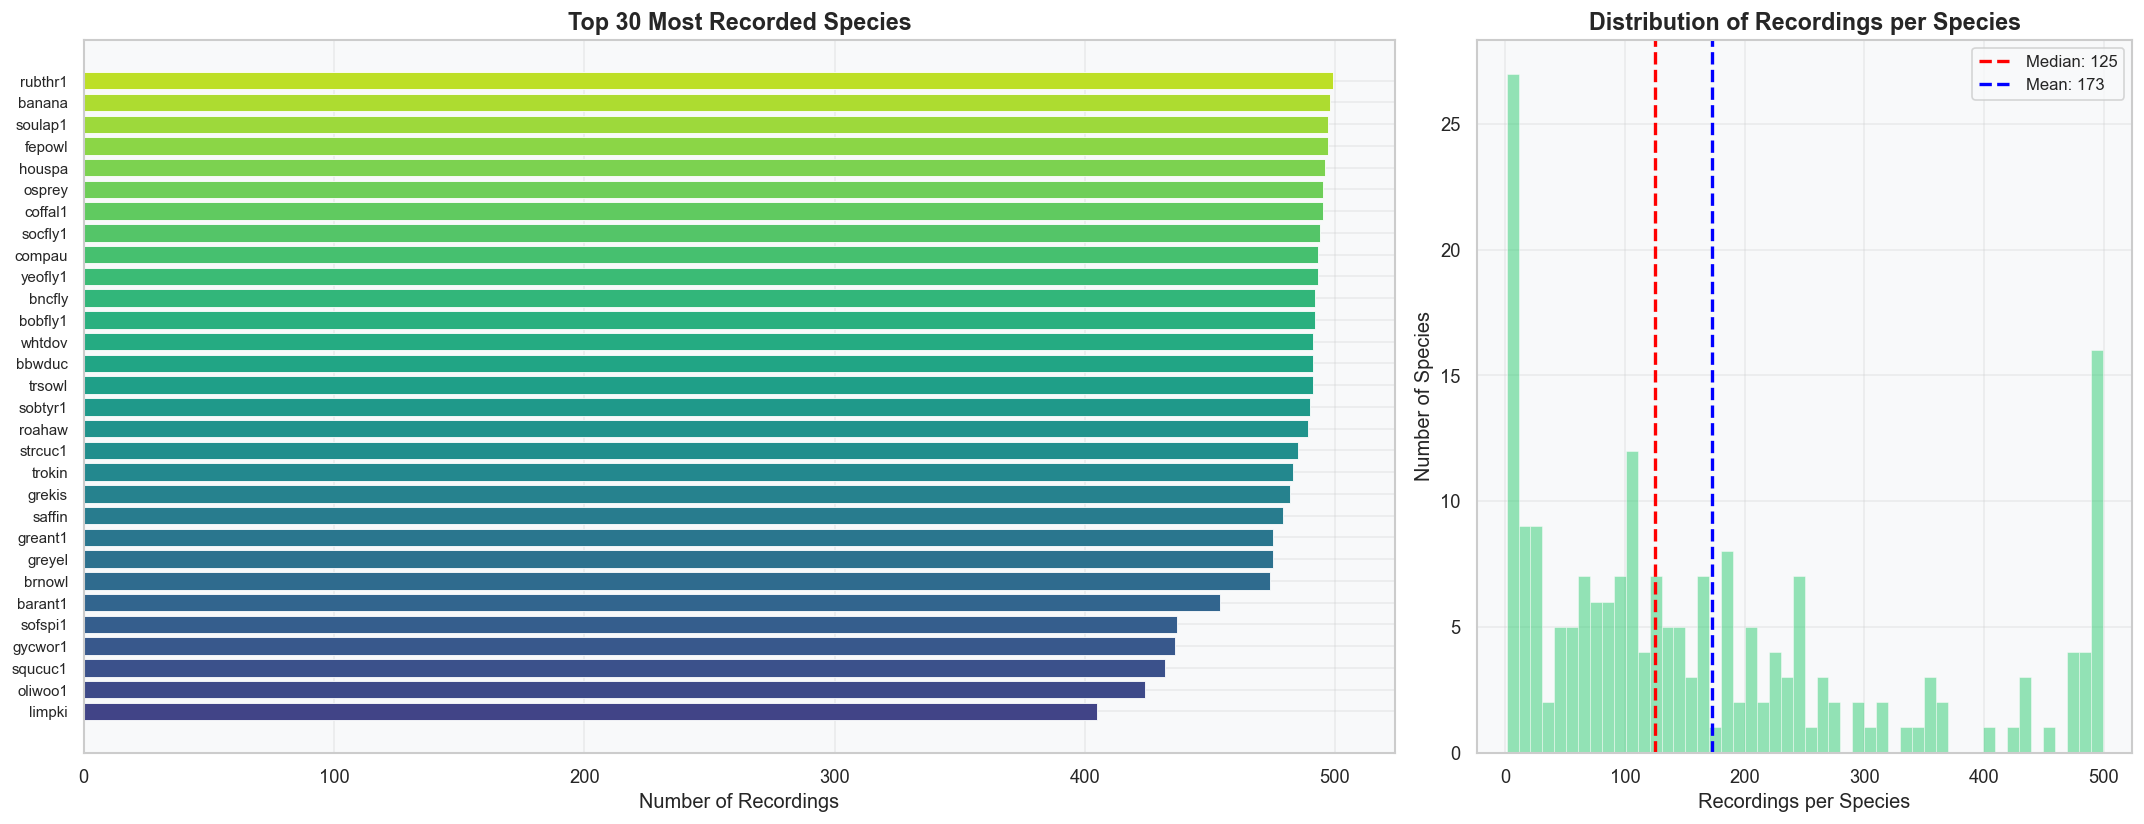

In [9]:
# =============================================================================
# Species Distribution Analysis
# =============================================================================
species_counts = df['primary_label'].value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

# Top 30 species
top_n = 30
colors = plt.cm.viridis(np.linspace(0.2, 0.9, top_n))  # creates a color gradient for the 30 bars.
axes[0].barh(
    species_counts.index[:top_n][::-1],  # y-axis labels (species names)
    species_counts.values[:top_n][::-1],  # x-axis lengths (number of recordings)
    color=colors,
    edgecolor='white',
    linewidth=0.5,
)
axes[0].set_xlabel("Number of Recordings")
axes[0].set_title(f"Top {top_n} Most Recorded Species", fontweight='bold')
axes[0].tick_params(axis='y', labelsize=9)

# Distribution histogram
axes[1].hist(species_counts.values, bins=50, color='#2ecc71', edgecolor='white', alpha=0.5, linewidth=0.5)
axes[1].axvline(
    species_counts.median(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Median: {species_counts.median():.0f}'
)
axes[1].axvline(
    species_counts.mean(),
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {species_counts.mean():.0f}'
)
axes[1].set_xlabel("Recordings per Species")
axes[1].set_ylabel("Number of Species")
axes[1].set_title(f"Distribution of Recordings per Species", fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('species_distribution.png', bbox_inches='tight', dpi=150)

# Summary stats
print(f"\n Species Distribution Summary:")
print(f"     Total species: {len(species_counts)}")
print(f"     Max recordings: {species_counts.max()} ({species_counts.idxmax()}")
print(f"     Min recordings: {species_counts.min()} ({species_counts.idxmin()}")
print(f"     Mean: {species_counts.mean():.1f} | Median {species_counts.median():.1f}")
print(f"     Std {species_counts.std():.1f}")
print(f"     Species with < 10 recordings: {(species_counts < 10).sum()}")
print(f"     Species with < 5 recordings: {(species_counts < 5).sum()}")

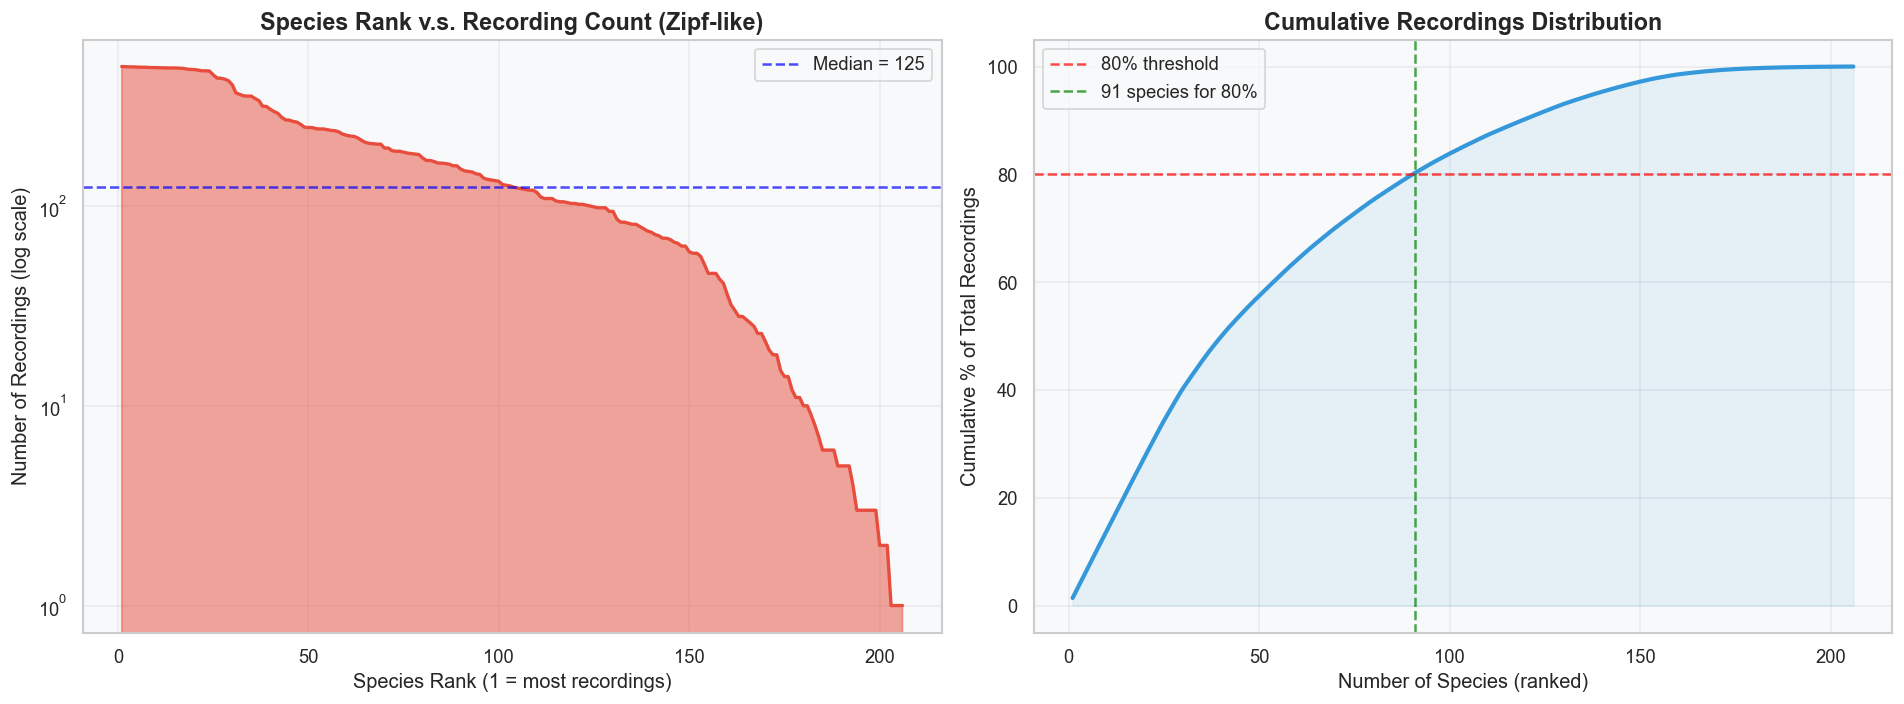


🔥Imbalance Ratio(max/min): 499.000000x
   Top 10% species hold 29.0% of recordings
   91 species (44.2%) account for 80% of data


In [11]:
# =============================================================================
# CLASS IMBALANCE ANALYSIS
# =============================================================================
# Goal: Visualize how unevenly the recordings are distributed across species.
# This is very important for BirdCLEF competitions because the dataset is
# heavily imbalanced (some species have thousands of recordings, others have <10).

# Create a figure with TWO subplots side-by-side
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# ─────────────────────────────────────────────────────────────────────────────
# LEFT PLOT: Log-scale rank plot (shows the classic "Zipf" distribution)
# ─────────────────────────────────────────────────────────────────────────────
ranks = np.arange(1, len(species_counts) + 1)  # [1, 2, 3, ..., N] → species ranking

# Plot species rank (x) vs number of recordings (y) on a logarithmic y-scale
# semilogy = log scale on y-axis only → makes the long-tail very visible
axes[0].semilogy(ranks, species_counts.values, color='#e74c3c', linewidth=2)

# Fill the area under the curve for a nicer visual effect
axes[0].fill_between(
    ranks,
    species_counts.values,
    alpha=0.5,
    color='#e74c3c'
)

# Add labels and title
axes[0].set_xlabel("Species Rank (1 = most recordings)")
axes[0].set_ylabel("Number of Recordings (log scale)")
axes[0].set_title(f"Species Rank v.s. Recording Count (Zipf-like)", fontweight='bold')

# Draw a horizontal line at the median value (helps see how many species are below average)
axes[0].axhline(
    y=species_counts.median(),
    color='blue',
    linestyle='--',
    alpha=0.7,
    label=f'Median = {species_counts.median():.0f}'
)
axes[0].legend()

# ─────────────────────────────────────────────────────────────────────────────
# RIGHT PLOT: Cumulative distribution (shows how many species cover most of the data)
# ─────────────────────────────────────────────────────────────────────────────
# Calculate cumulative percentage of total recordings
cumulative = np.cumsum(species_counts.values) / species_counts.values.sum() * 100

# Plot the cumulative curve
axes[1].plot(ranks, cumulative, color='#3498db', linewidth=2.5)

# Light fill under the curve
axes[1].fill_between(ranks, cumulative, alpha=0.1, color='#3498db')

# Draw 80% threshold line (classic "80/20 rule" check)
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% threshold')

# Find how many species are needed to reach 80% of all recordings
species_at_80 = np.searchsorted(cumulative, 80) + 1
axes[1].axvline(
    x=species_at_80, 
    color='green', 
    linestyle='--', 
    alpha=0.7, 
    label=f'{species_at_80} species for 80%'
)

# Add labels and title
axes[1].set_xlabel("Number of Species (ranked)")
axes[1].set_ylabel("Cumulative % of Total Recordings")
axes[1].set_title(f"Cumulative Recordings Distribution", fontweight='bold')
axes[1].legend()

# ─────────────────────────────────────────────────────────────────────────────
# Final touches & output
# ─────────────────────────────────────────────────────────────────────────────
plt.tight_layout()
plt.savefig('class_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n🔥Imbalance Ratio(max/min): {species_counts.max() / species_counts.min():1f}x")
print(f"   Top 10% species hold {cumulative[int(len(cumulative)*0.1)]:.1f}% of recordings")
print(f"   {species_at_80} species ({species_at_80/len(species_counts)*100:.1f}%) account for 80% of data")

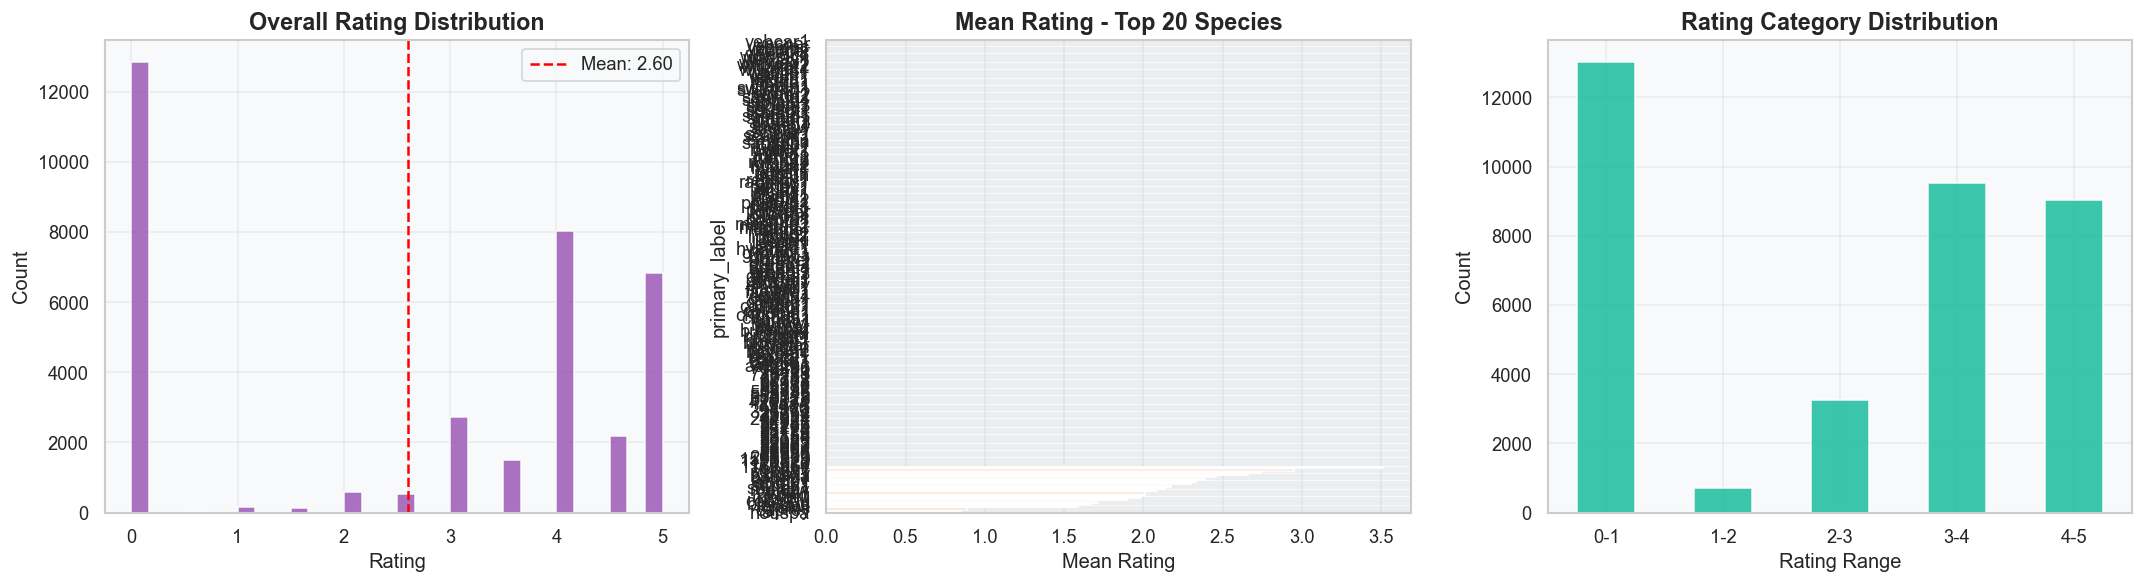

In [12]:
# =============================================================================
# Cell 6: Rating Distribution Analysis
# =============================================================================

if 'rating' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Overall rating distribution
    df['rating'].hist(bins=30, ax=axes[0], color='#9b59b6', edgecolor='white',
                      alpha=0.85)
    axes[0].set_xlabel("Rating")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Overall Rating Distribution", fontweight='bold')
    axes[0].axvline(df['rating'].mean(), color='red', linestyle='--',
                    label=f"Mean: {df['rating'].mean():.2f}")
    axes[0].legend()

    # Rating vs species (top 20)
    top20 = species_counts.index[:20]
    df_top20 = df[df['primary_label'].isin(top20)]
    rating_by_species = df_top20.groupby('primary_label')['rating'].mean().sort_values(ascending=True)
    rating_by_species.plot.barh(
        ax=axes[1], 
        color=plt.cm.RdYlGn(
        np.linspace(0.2, 0.9, len(rating_by_species))), 
        edgecolor='white'
    )
    axes[1].set_xlabel("Mean Rating")
    axes[1].set_title("Mean Rating - Top 20 Species", fontweight='bold')

    # Rating category breakdown
    bins = [0, 1, 2, 3, 4, 5]
    labels = ['0-1', '1-2', '2-3', '3-4', '4-5']
    df['rating_bin'] = pd.cut(df['rating'], bins=bins, labels=labels, include_lowest=True)
    rating_dist = df['rating_bin'].value_counts().sort_index()
    rating_dist.plot.bar(ax=axes[2], color='#1abc9c', edgecolor='white', alpha=0.85)
    axes[2].set_xlabel("Rating Range")
    axes[2].set_ylabel("Count")
    axes[2].set_title("Rating Category Distribution", fontweight='bold')
    axes[2].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig('rating_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()

    df.drop(columns=['rating_bin'], inplace=True, errors='ignore')

🏷️ Secondary Labels Analysis:
   Recordings with secondary labels: 4372 (12.3%)
   Unique secondary labels: 161


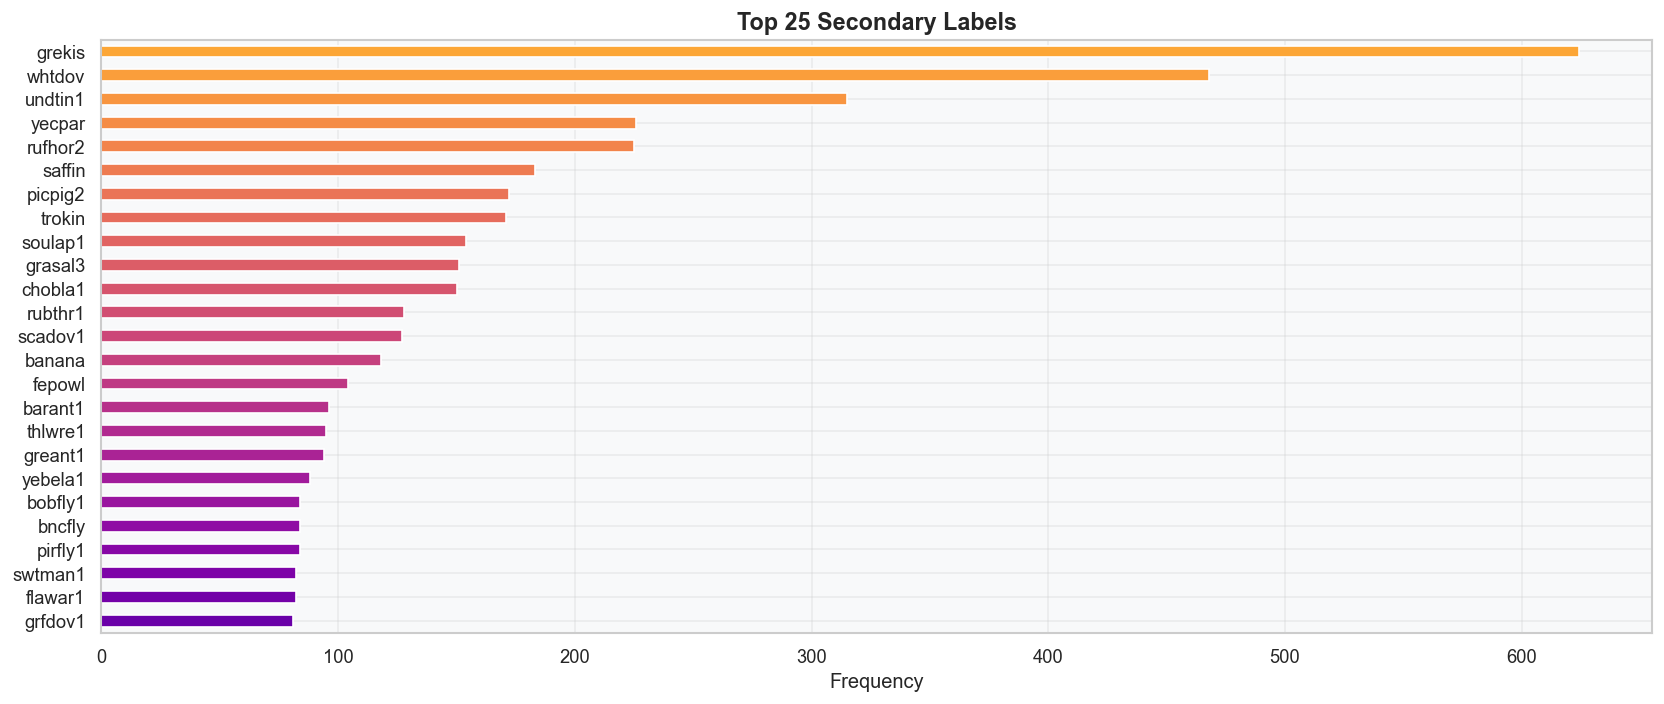

In [13]:
# =============================================================================
# Cell 7: Secondary Labels Analysis
# =============================================================================

def parse_secondary_labels(series):
    """Efficiently parse secondary labels from string representation."""
    all_labels = []
    for val in series.dropna():
        if isinstance(val, str) and val not in ('[]', ''):
            # Handle both formats: "['a', 'b']" and "a b"
            cleaned = val.strip("[]'\"").replace("'", "").replace('"', '')
            labels = [l.strip() for l in cleaned.split(',') if l.strip()]
            all_labels.extend(labels)
    return Counter(all_labels)

if 'secondary_labels' in df.columns:
    secondary_counts = parse_secondary_labels(df['secondary_labels'])

    has_secondary = df['secondary_labels'].apply(
        lambda x: isinstance(x, str) and x not in ('[]', '', 'nan')
    ).sum()

    print(f"🏷️ Secondary Labels Analysis:")
    print(f"   Recordings with secondary labels: {has_secondary} ({has_secondary/len(df)*100:.1f}%)")
    print(f"   Unique secondary labels: {len(secondary_counts)}")

    if secondary_counts:
        top_secondary = pd.Series(dict(secondary_counts.most_common(25)))

        fig, ax = plt.subplots(figsize=(14, 6))
        top_secondary.sort_values().plot.barh(
            ax=ax, color=plt.cm.plasma(np.linspace(0.2, 0.8, len(top_secondary))),
            edgecolor='white'
        )
        ax.set_xlabel("Frequency")
        ax.set_title("Top 25 Secondary Labels", fontweight='bold')
        plt.tight_layout()
        plt.savefig('secondary_labels.png', bbox_inches='tight', dpi=150)
        plt.show()

In [14]:
# =============================================================================
# Cell 8: Audio File Analysis (Optimized with parallel processing)
# =============================================================================

def get_audio_metadata_fast(filepath):
    """Extract audio metadata without loading full audio."""
    try:
        info = librosa.get_duration(path=filepath)
        return {'filepath': str(filepath), 'duration': info, 'valid': True}
    except Exception as e:
        return {'filepath': str(filepath), 'duration': 0, 'valid': False}

# Sample files for analysis (stratified by species if possible)
sample_size = min(2000, len(df))
np.random.seed(42)

# Stratified sample: pick files from diverse species
if sample_size < len(df):
    sampled_df = df.groupby('primary_label', group_keys=False).apply(
        lambda x: x.sample(min(len(x), max(1, sample_size // df['primary_label'].nunique())),
                          random_state=42)
    ).head(sample_size)
else:
    sampled_df = df.copy()

filepaths = [AUDIO_DIR / f for f in sampled_df['filename'].values]

print(f"🔊 Analyzing {len(filepaths)} audio files (parallel processing)...")

# Parallel metadata extraction
audio_meta = []
with ThreadPoolExecutor(max_workers=8) as executor:
    futures = {executor.submit(get_audio_metadata_fast, fp): fp for fp in filepaths}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Extracting metadata"):
        audio_meta.append(future.result())

audio_df = pd.DataFrame(audio_meta)
valid_audio = audio_df[audio_df['valid']]

print(f"\n✅ Successfully analyzed: {len(valid_audio)}/{len(audio_df)} files")
print(f"📏 Duration Statistics:")
print(f"   Mean: {valid_audio['duration'].mean():.2f}s")
print(f"   Median: {valid_audio['duration'].median():.2f}s")
print(f"   Min: {valid_audio['duration'].min():.2f}s")
print(f"   Max: {valid_audio['duration'].max():.2f}s")
print(f"   Total audio: {valid_audio['duration'].sum()/3600:.1f} hours")

🔊 Analyzing 1729 audio files (parallel processing)...


Extracting metadata:   0%|          | 0/1729 [00:00<?, ?it/s]


✅ Successfully analyzed: 1729/1729 files
📏 Duration Statistics:
   Mean: 32.37s
   Median: 21.66s
   Min: 0.01s
   Max: 487.80s
   Total audio: 15.5 hours


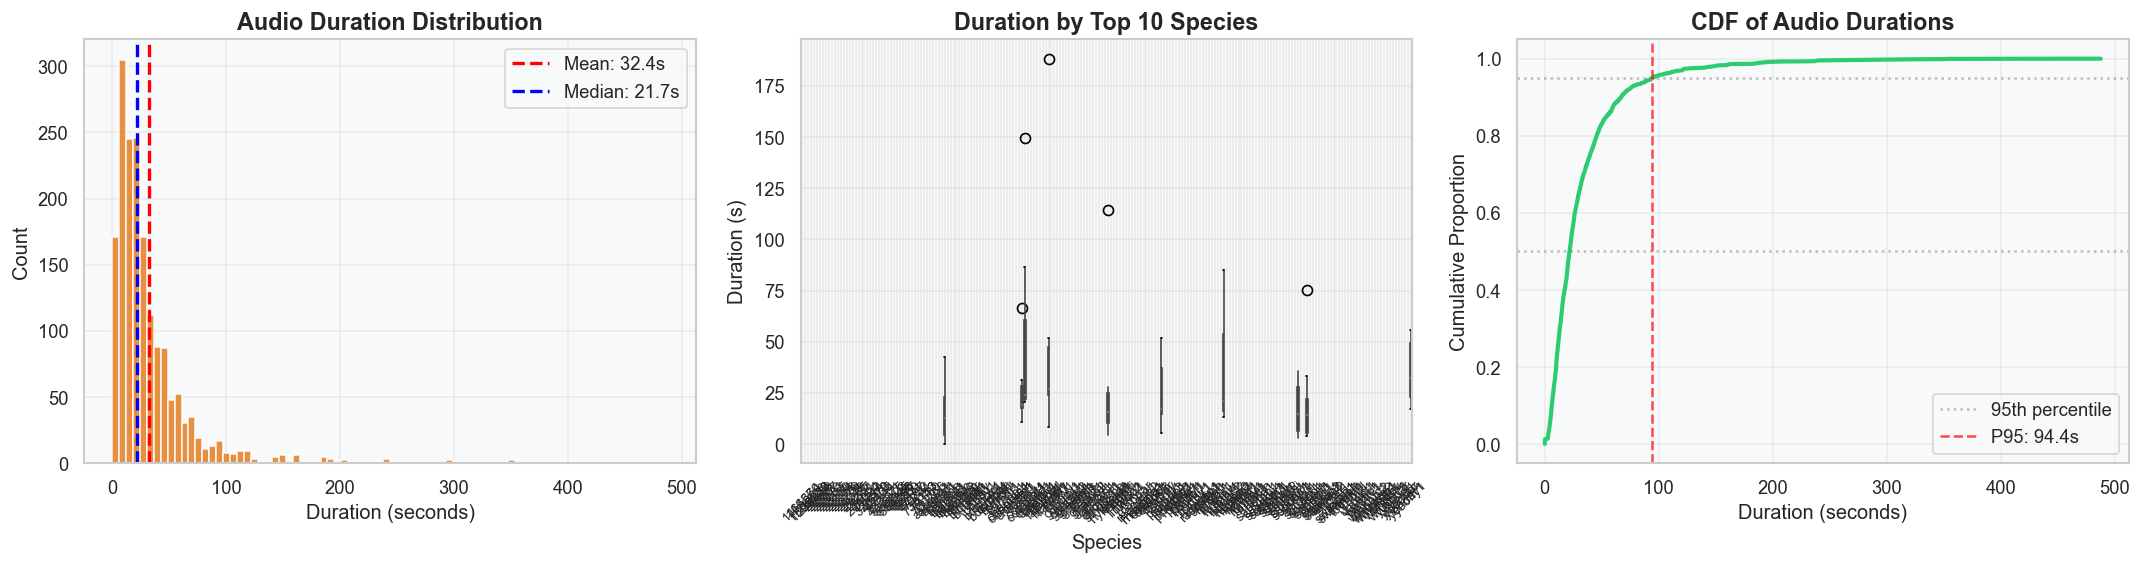

In [15]:
# =============================================================================
# Cell 9: Duration Distribution Visualization
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(valid_audio['duration'], bins=80, color='#e67e22', edgecolor='white',
             alpha=0.85)
axes[0].axvline(valid_audio['duration'].mean(), color='red', linestyle='--',
                linewidth=2, label=f"Mean: {valid_audio['duration'].mean():.1f}s")
axes[0].axvline(valid_audio['duration'].median(), color='blue', linestyle='--',
                linewidth=2, label=f"Median: {valid_audio['duration'].median():.1f}s")
axes[0].set_xlabel("Duration (seconds)")
axes[0].set_ylabel("Count")
axes[0].set_title("Audio Duration Distribution", fontweight='bold')
axes[0].legend()

# Box plot by top species
sampled_df_with_dur = sampled_df.copy()
sampled_df_with_dur['duration'] = valid_audio['duration'].values[:len(sampled_df_with_dur)]
top10_species = species_counts.index[:10]
mask = sampled_df_with_dur['primary_label'].isin(top10_species)
if mask.sum() > 0:
    filtered = sampled_df_with_dur[mask]
    filtered.boxplot(column='duration', by='primary_label', ax=axes[1],
                     vert=True, patch_artist=True)
    axes[1].set_xlabel("Species")
    axes[1].set_ylabel("Duration (s)")
    axes[1].set_title("Duration by Top 10 Species", fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45, labelsize=8)
    fig.suptitle('')  # Remove automatic title from boxplot

# CDF of durations
sorted_dur = np.sort(valid_audio['duration'].values)
cdf = np.arange(1, len(sorted_dur) + 1) / len(sorted_dur)
axes[2].plot(sorted_dur, cdf, color='#2ecc71', linewidth=2.5)
axes[2].set_xlabel("Duration (seconds)")
axes[2].set_ylabel("Cumulative Proportion")
axes[2].set_title("CDF of Audio Durations", fontweight='bold')
axes[2].axhline(0.5, color='gray', linestyle=':', alpha=0.5)
axes[2].axhline(0.95, color='gray', linestyle=':', alpha=0.5, label='95th percentile')
p95 = np.percentile(sorted_dur, 95)
axes[2].axvline(p95, color='red', linestyle='--', alpha=0.7, label=f'P95: {p95:.1f}s')
axes[2].legend()

plt.tight_layout()
plt.savefig('duration_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


🐦 Species: rubthr1 | File: rubthr1/XC692377.ogg


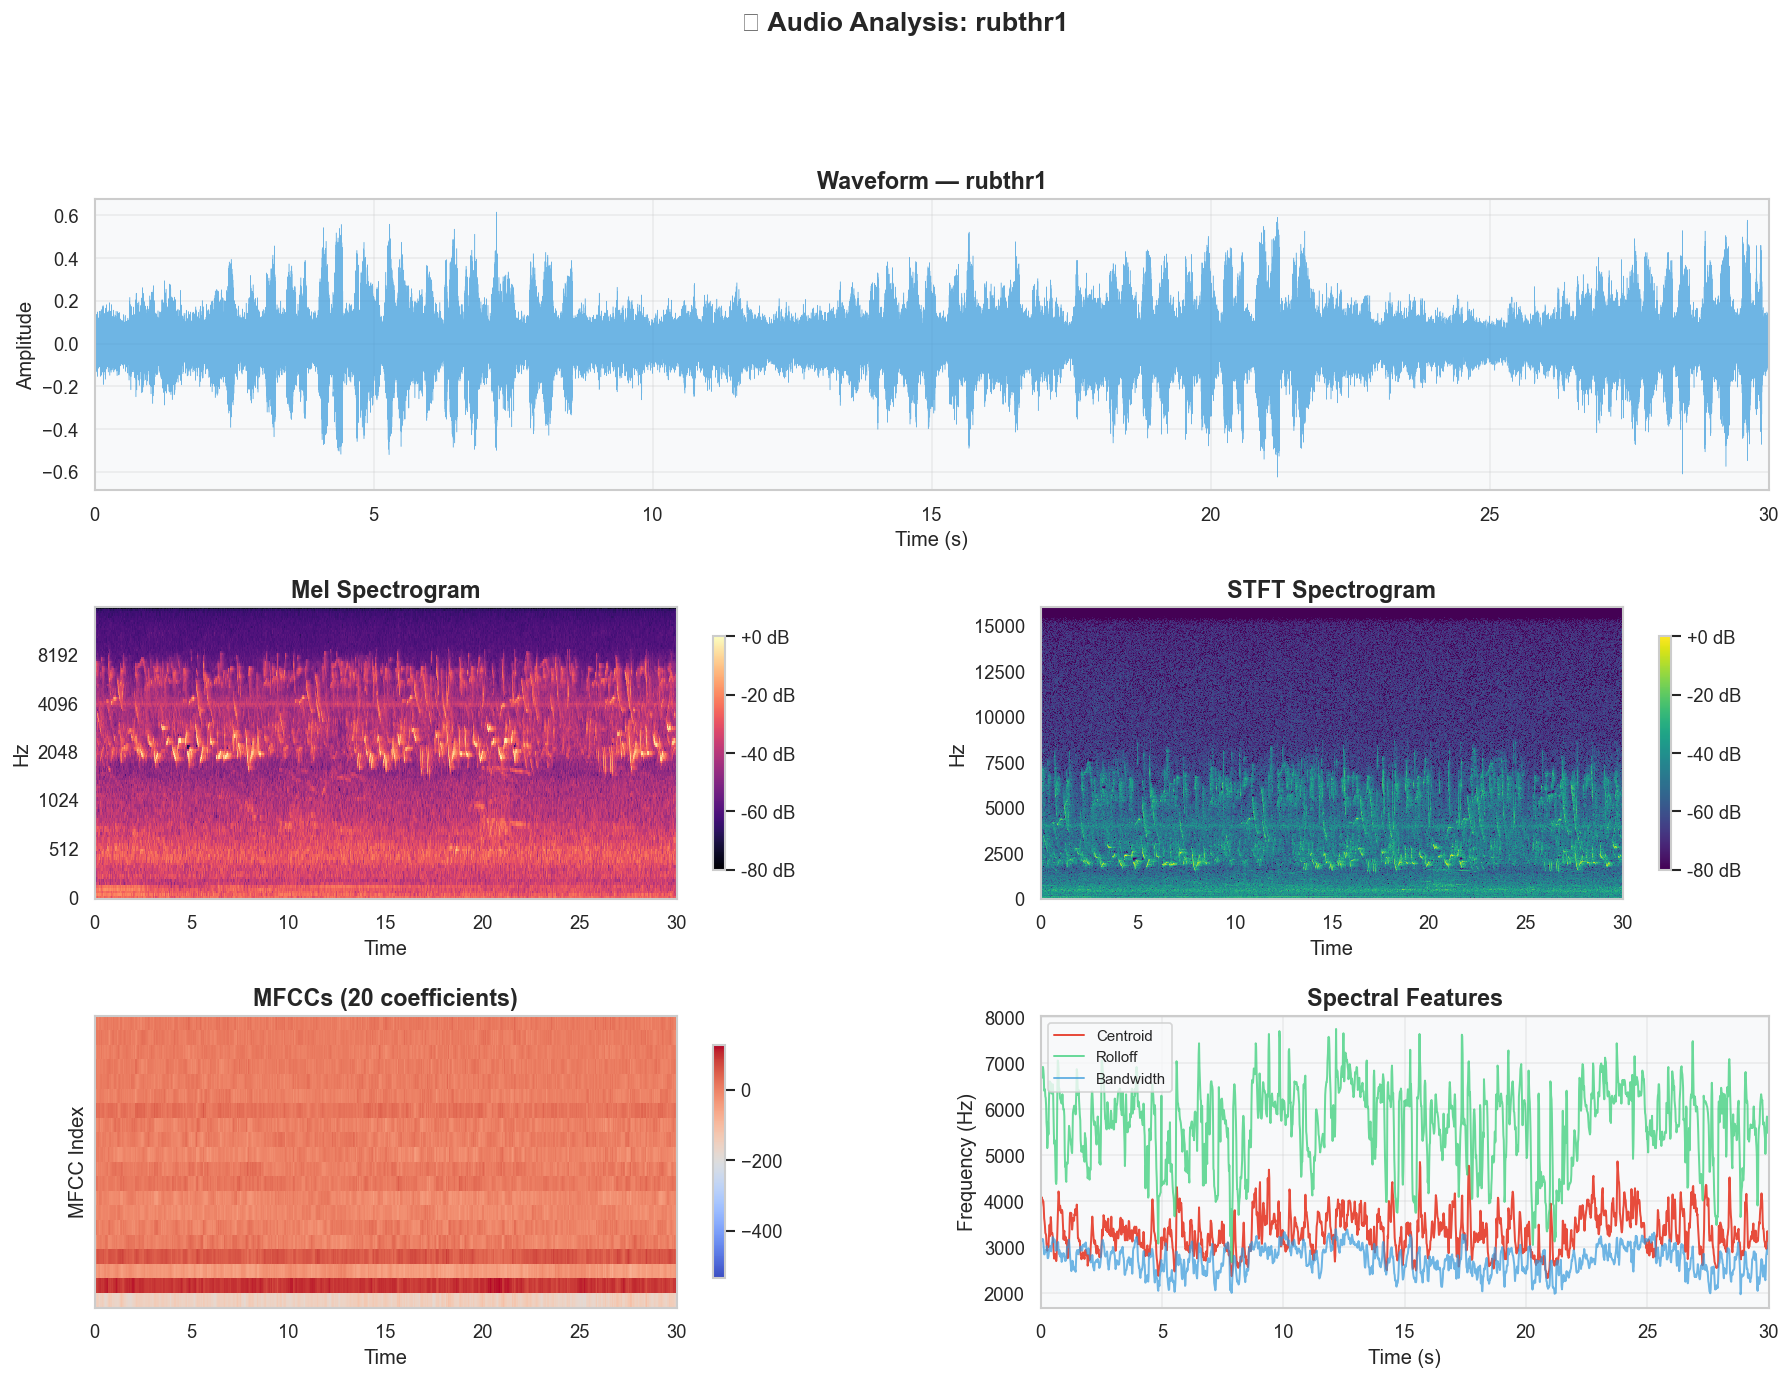

   Duration: 30.00s

🐦 Species: banana | File: banana/XC33682.ogg


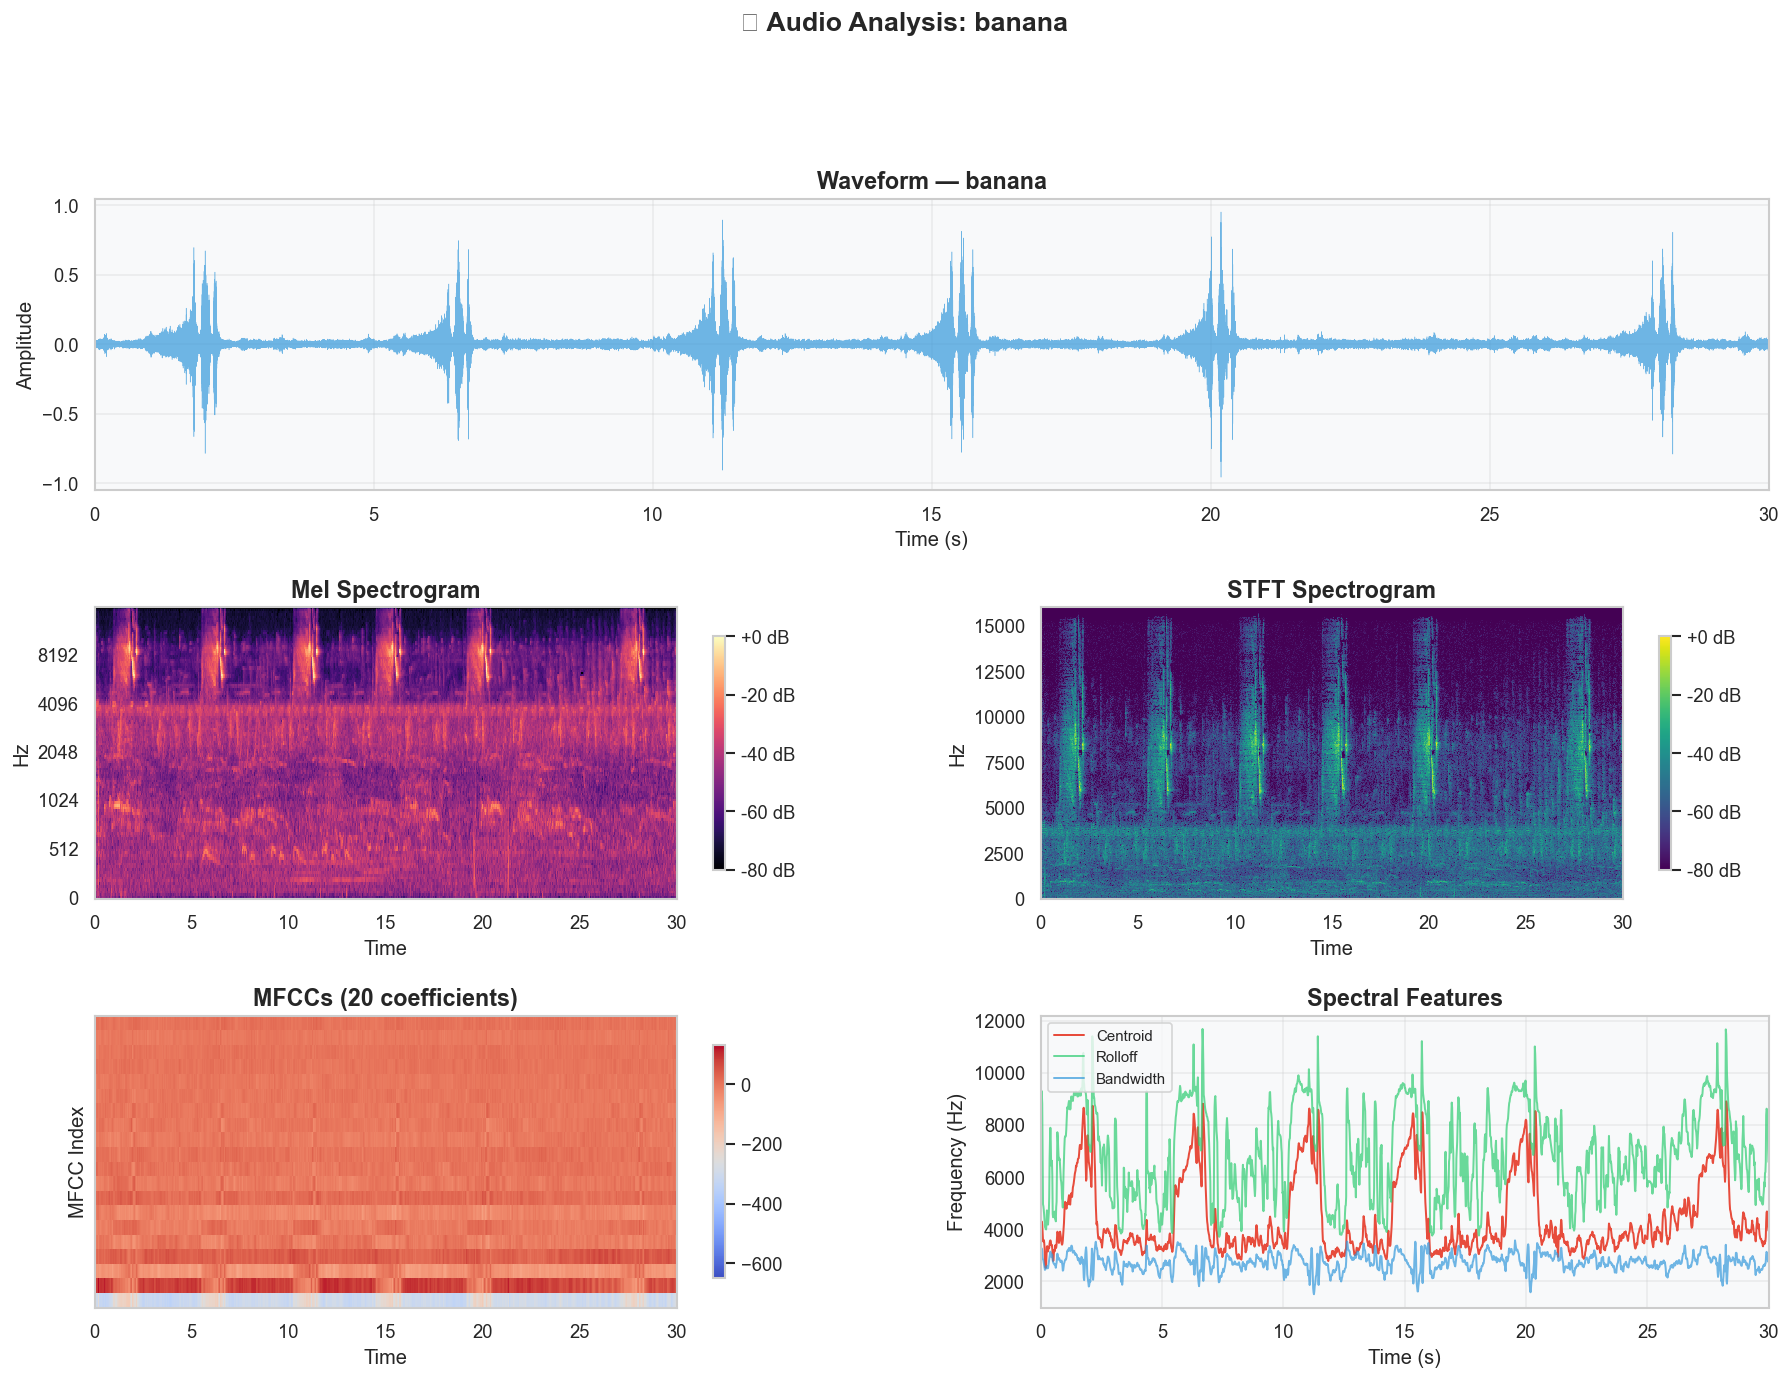

   Duration: 30.00s

🐦 Species: soulap1 | File: soulap1/XC489125.ogg


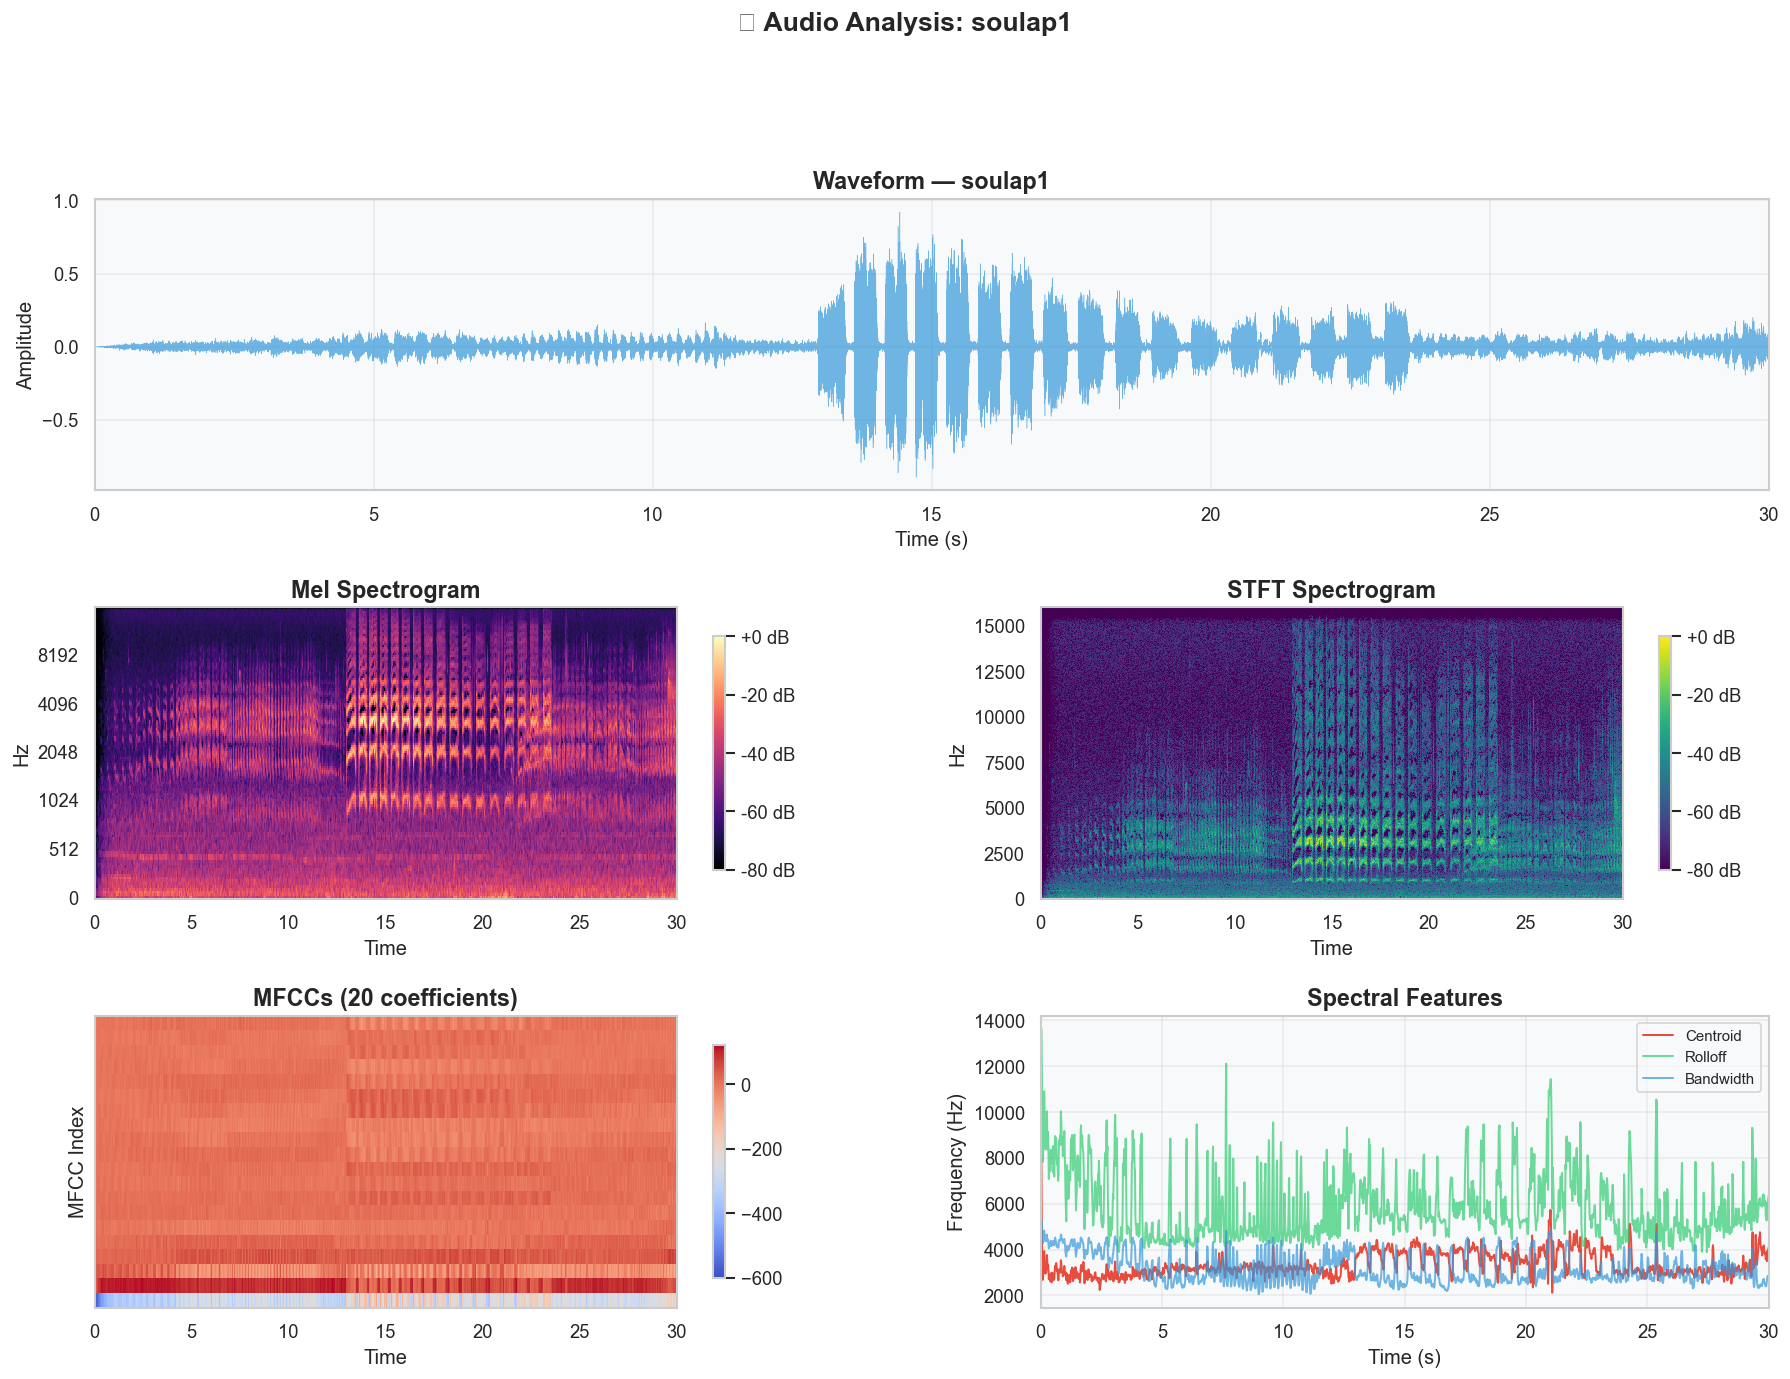

   Duration: 30.00s

🐦 Species: fepowl | File: fepowl/iNat905413.ogg


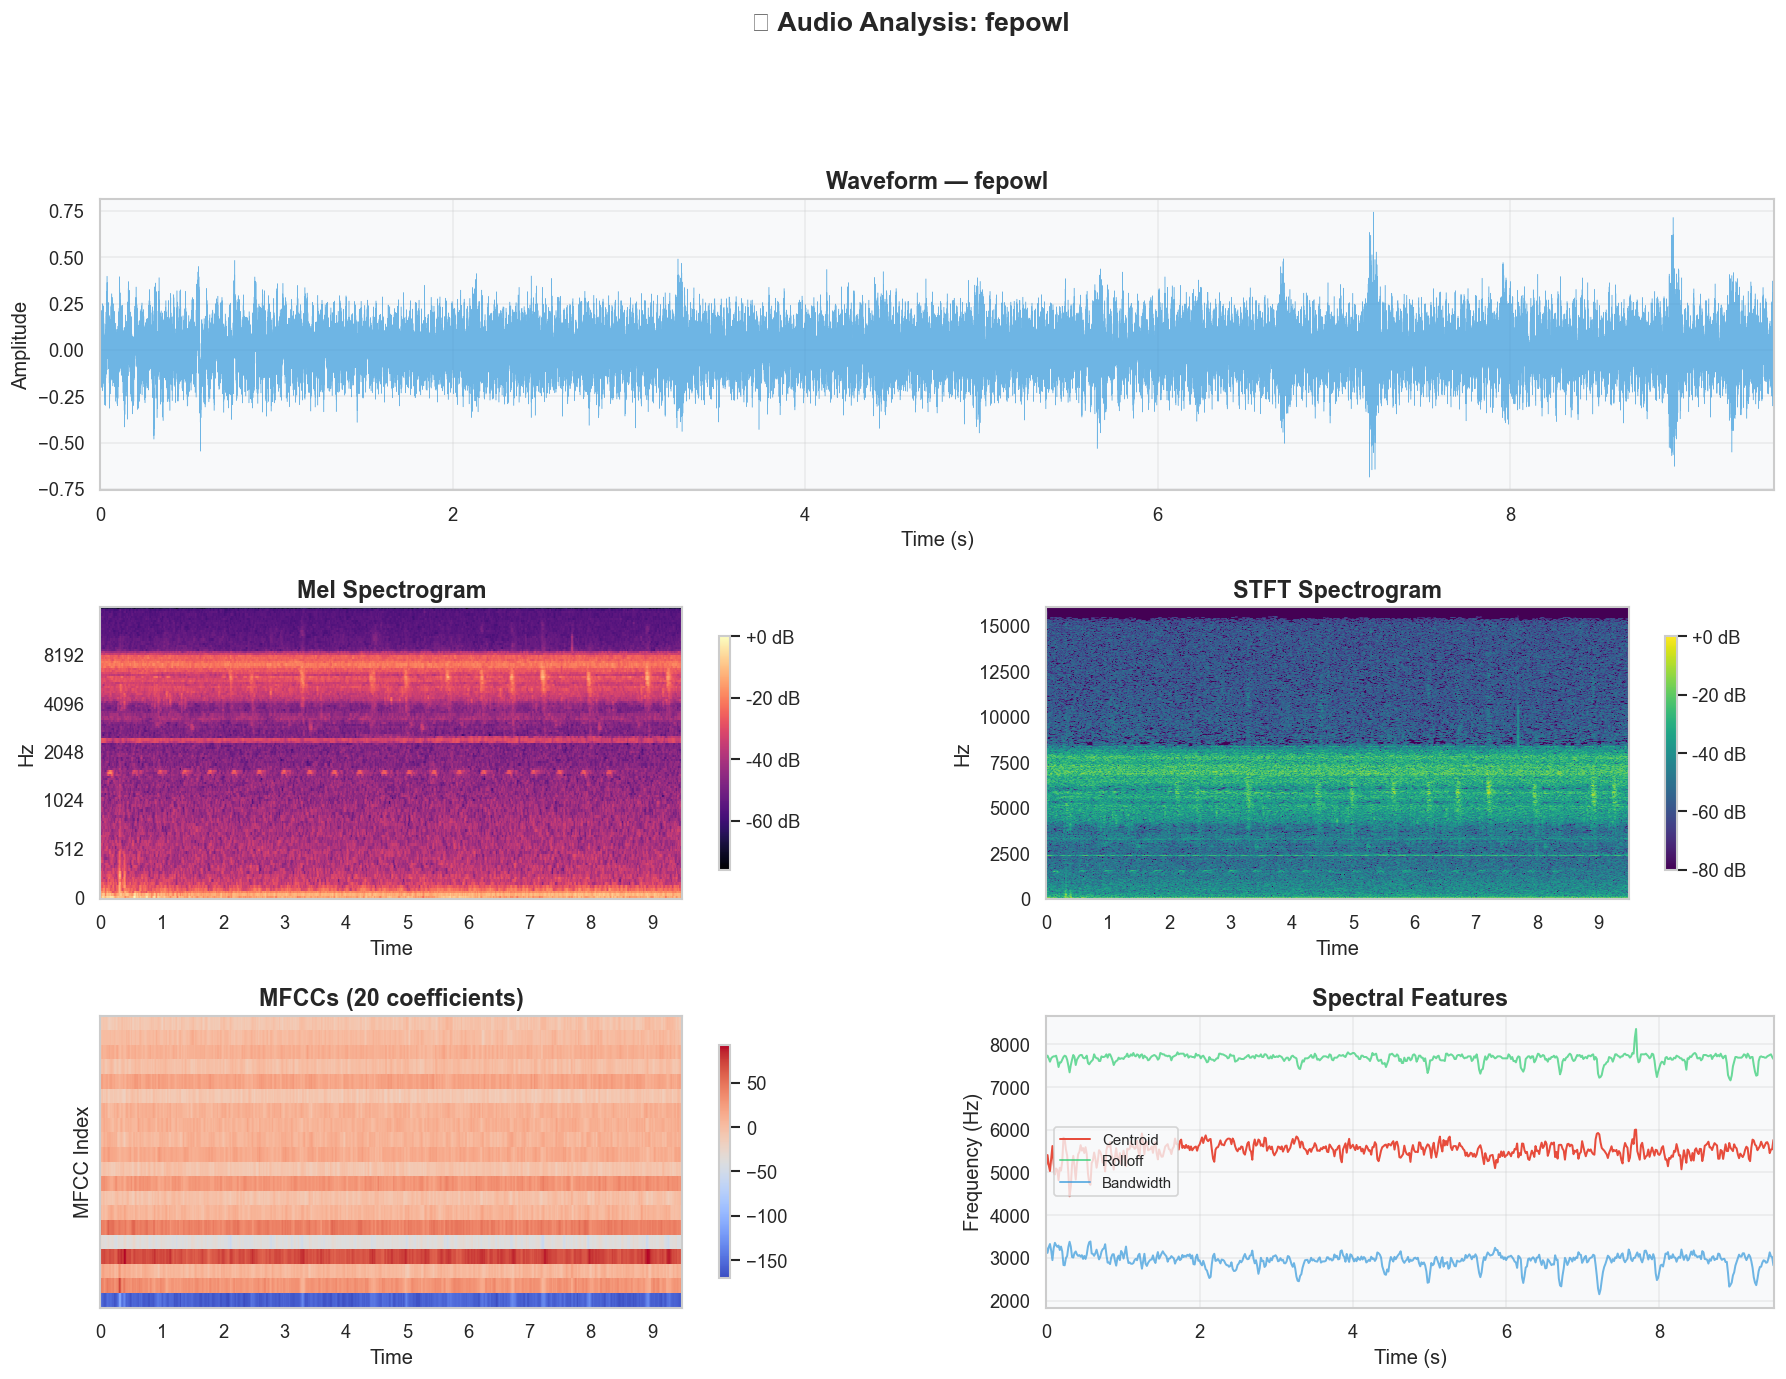

   Duration: 9.50s

🐦 Species: houspa | File: houspa/iNat665592.ogg


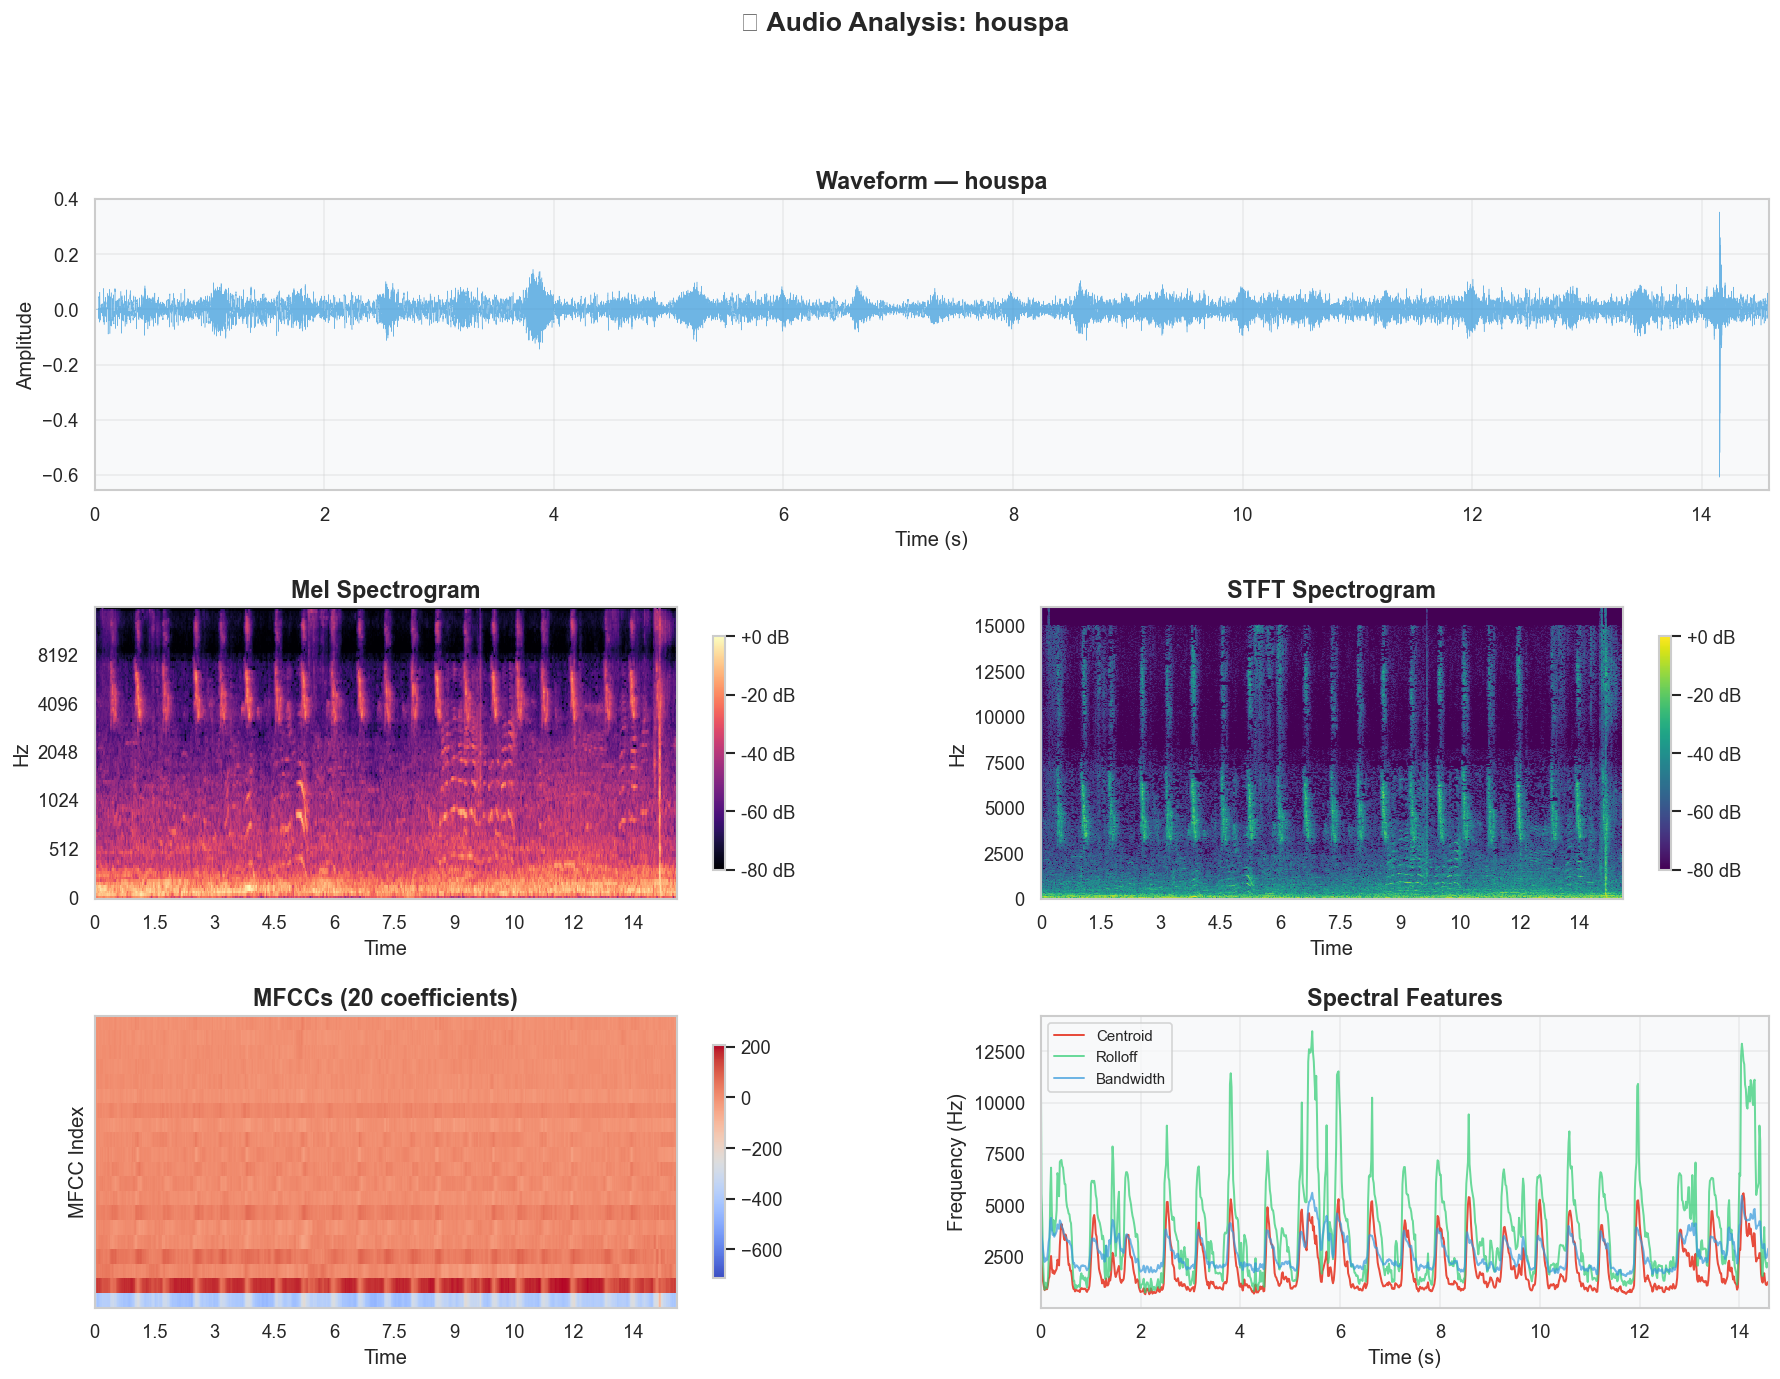

   Duration: 14.58s


In [16]:
# =============================================================================
# Cell 10: Spectrogram Analysis (Optimized)
# =============================================================================

def plot_audio_analysis(filepath, species_name, sr=32000, max_duration=30):
    """
    Comprehensive audio analysis for a single file.
    Optimized: limits duration, uses efficient FFT parameters.
    """
    y, sr = librosa.load(filepath, sr=sr, duration=max_duration)
    duration = len(y) / sr

    fig = plt.figure(figsize=(18, 12))
    gs = gridspec.GridSpec(3, 2, hspace=0.4, wspace=0.3)

    # Waveform
    ax1 = fig.add_subplot(gs[0, :])
    times = np.linspace(0, duration, len(y))
    ax1.plot(times, y, color='#3498db', linewidth=0.3, alpha=0.7)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.set_title(f"Waveform — {species_name}", fontweight='bold')
    ax1.set_xlim(0, duration)

    # Mel Spectrogram
    ax2 = fig.add_subplot(gs[1, 0])
    n_fft = 2048
    hop_length = 512
    S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128,
                                            n_fft=n_fft, hop_length=hop_length,
                                            fmax=sr//2)
    S_mel_db = librosa.power_to_db(S_mel, ref=np.max)
    img1 = librosa.display.specshow(S_mel_db, sr=sr, hop_length=hop_length,
                                     x_axis='time', y_axis='mel', ax=ax2,
                                     cmap='magma')
    fig.colorbar(img1, ax=ax2, format='%+2.0f dB', shrink=0.8)
    ax2.set_title("Mel Spectrogram", fontweight='bold')

    # Standard Spectrogram
    ax3 = fig.add_subplot(gs[1, 1])
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img2 = librosa.display.specshow(S_db, sr=sr, hop_length=hop_length,
                                     x_axis='time', y_axis='hz', ax=ax3,
                                     cmap='viridis')
    fig.colorbar(img2, ax=ax3, format='%+2.0f dB', shrink=0.8)
    ax3.set_title("STFT Spectrogram", fontweight='bold')
    ax3.set_ylim(0, sr // 2)

    # MFCCs
    ax4 = fig.add_subplot(gs[2, 0])
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, n_fft=n_fft,
                                  hop_length=hop_length)
    img3 = librosa.display.specshow(mfccs, sr=sr, hop_length=hop_length,
                                     x_axis='time', ax=ax4, cmap='coolwarm')
    fig.colorbar(img3, ax=ax4, shrink=0.8)
    ax4.set_title("MFCCs (20 coefficients)", fontweight='bold')
    ax4.set_ylabel("MFCC Index")

    # Spectral features over time
    ax5 = fig.add_subplot(gs[2, 1])
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr,
                                                          hop_length=hop_length)[0]
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr,
                                                         hop_length=hop_length)[0]
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr,
                                                             hop_length=hop_length)[0]
    frames = np.arange(len(spectral_centroid))
    t = librosa.frames_to_time(frames, sr=sr, hop_length=hop_length)

    ax5.plot(t, spectral_centroid, label='Centroid', color='#e74c3c', linewidth=1.2)
    ax5.plot(t, spectral_rolloff, label='Rolloff', color='#2ecc71', linewidth=1.2, alpha=0.7)
    ax5.plot(t, spectral_bandwidth, label='Bandwidth', color='#3498db', linewidth=1.2, alpha=0.7)
    ax5.set_xlabel("Time (s)")
    ax5.set_ylabel("Frequency (Hz)")
    ax5.set_title("Spectral Features", fontweight='bold')
    ax5.legend(fontsize=9)
    ax5.set_xlim(0, duration)

    fig.suptitle(f"🐦 Audio Analysis: {species_name}", fontsize=16, fontweight='bold', y=1.01)
    plt.savefig(f'audio_analysis_{species_name}.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Cleanup
    del y, S_mel, S_mel_db, S, S_db, mfccs
    gc.collect()

    return duration

# Analyze representative samples from different species
np.random.seed(42)
sample_species = species_counts.index[:5]  # Top 5 species

for species in sample_species:
    species_files = df[df['primary_label'] == species]['filename'].values
    chosen_file = np.random.choice(species_files)
    filepath = AUDIO_DIR / chosen_file

    if filepath.exists():
        print(f"\n{'='*60}")
        print(f"🐦 Species: {species} | File: {chosen_file}")
        print(f"{'='*60}")

        # Play audio
        display(ipd.Audio(filepath))

        # Plot analysis
        dur = plot_audio_analysis(filepath, species)
        print(f"   Duration: {dur:.2f}s")
    else:
        print(f"⚠️ File not found: {filepath}")

In [17]:
# =============================================================================
# Cell 11: Cross-Species Spectral Comparison
# =============================================================================

def extract_spectral_features(filepath, sr=32000, max_duration=15):
    """Extract summary spectral features for a file."""
    try:
        y, sr = librosa.load(filepath, sr=sr, duration=max_duration)
        features = {
            'spectral_centroid_mean': librosa.feature.spectral_centroid(y=y, sr=sr).mean(),
            'spectral_centroid_std': librosa.feature.spectral_centroid(y=y, sr=sr).std(),
            'spectral_bandwidth_mean': librosa.feature.spectral_bandwidth(y=y, sr=sr).mean(),
            'spectral_rolloff_mean': librosa.feature.spectral_rolloff(y=y, sr=sr).mean(),
            'zero_crossing_rate_mean': librosa.feature.zero_crossing_rate(y).mean(),
            'rms_mean': librosa.feature.rms(y=y).mean(),
            'rms_std': librosa.feature.rms(y=y).std(),
        }
        # MFCCs summary
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            features[f'mfcc_{i}_mean'] = mfccs[i].mean()
            features[f'mfcc_{i}_std'] = mfccs[i].std()

        del y, mfccs
        return features
    except Exception:
        return None

# Extract features for a subset
n_compare = min(500, len(df))
compare_df = df.groupby('primary_label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), max(1, n_compare // df['primary_label'].nunique())),
                       random_state=42)
).head(n_compare)

print(f"🔬 Extracting spectral features from {len(compare_df)} files...")

feature_records = []
labels = []

with ThreadPoolExecutor(max_workers=4) as executor:
    future_map = {}
    for idx, row in compare_df.iterrows():
        fp = AUDIO_DIR / row['filename']
        if fp.exists():
            future = executor.submit(extract_spectral_features, fp)
            future_map[future] = row['primary_label']

    for future in tqdm(as_completed(future_map), total=len(future_map),
                       desc="Feature extraction"):
        result = future.result()
        if result is not None:
            feature_records.append(result)
            labels.append(future_map[future])

features_df = pd.DataFrame(feature_records)
features_df['species'] = labels

print(f"✅ Extracted features for {len(features_df)} files")

🔬 Extracting spectral features from 408 files...


Feature extraction:   0%|          | 0/408 [00:00<?, ?it/s]

✅ Extracted features for 408 files


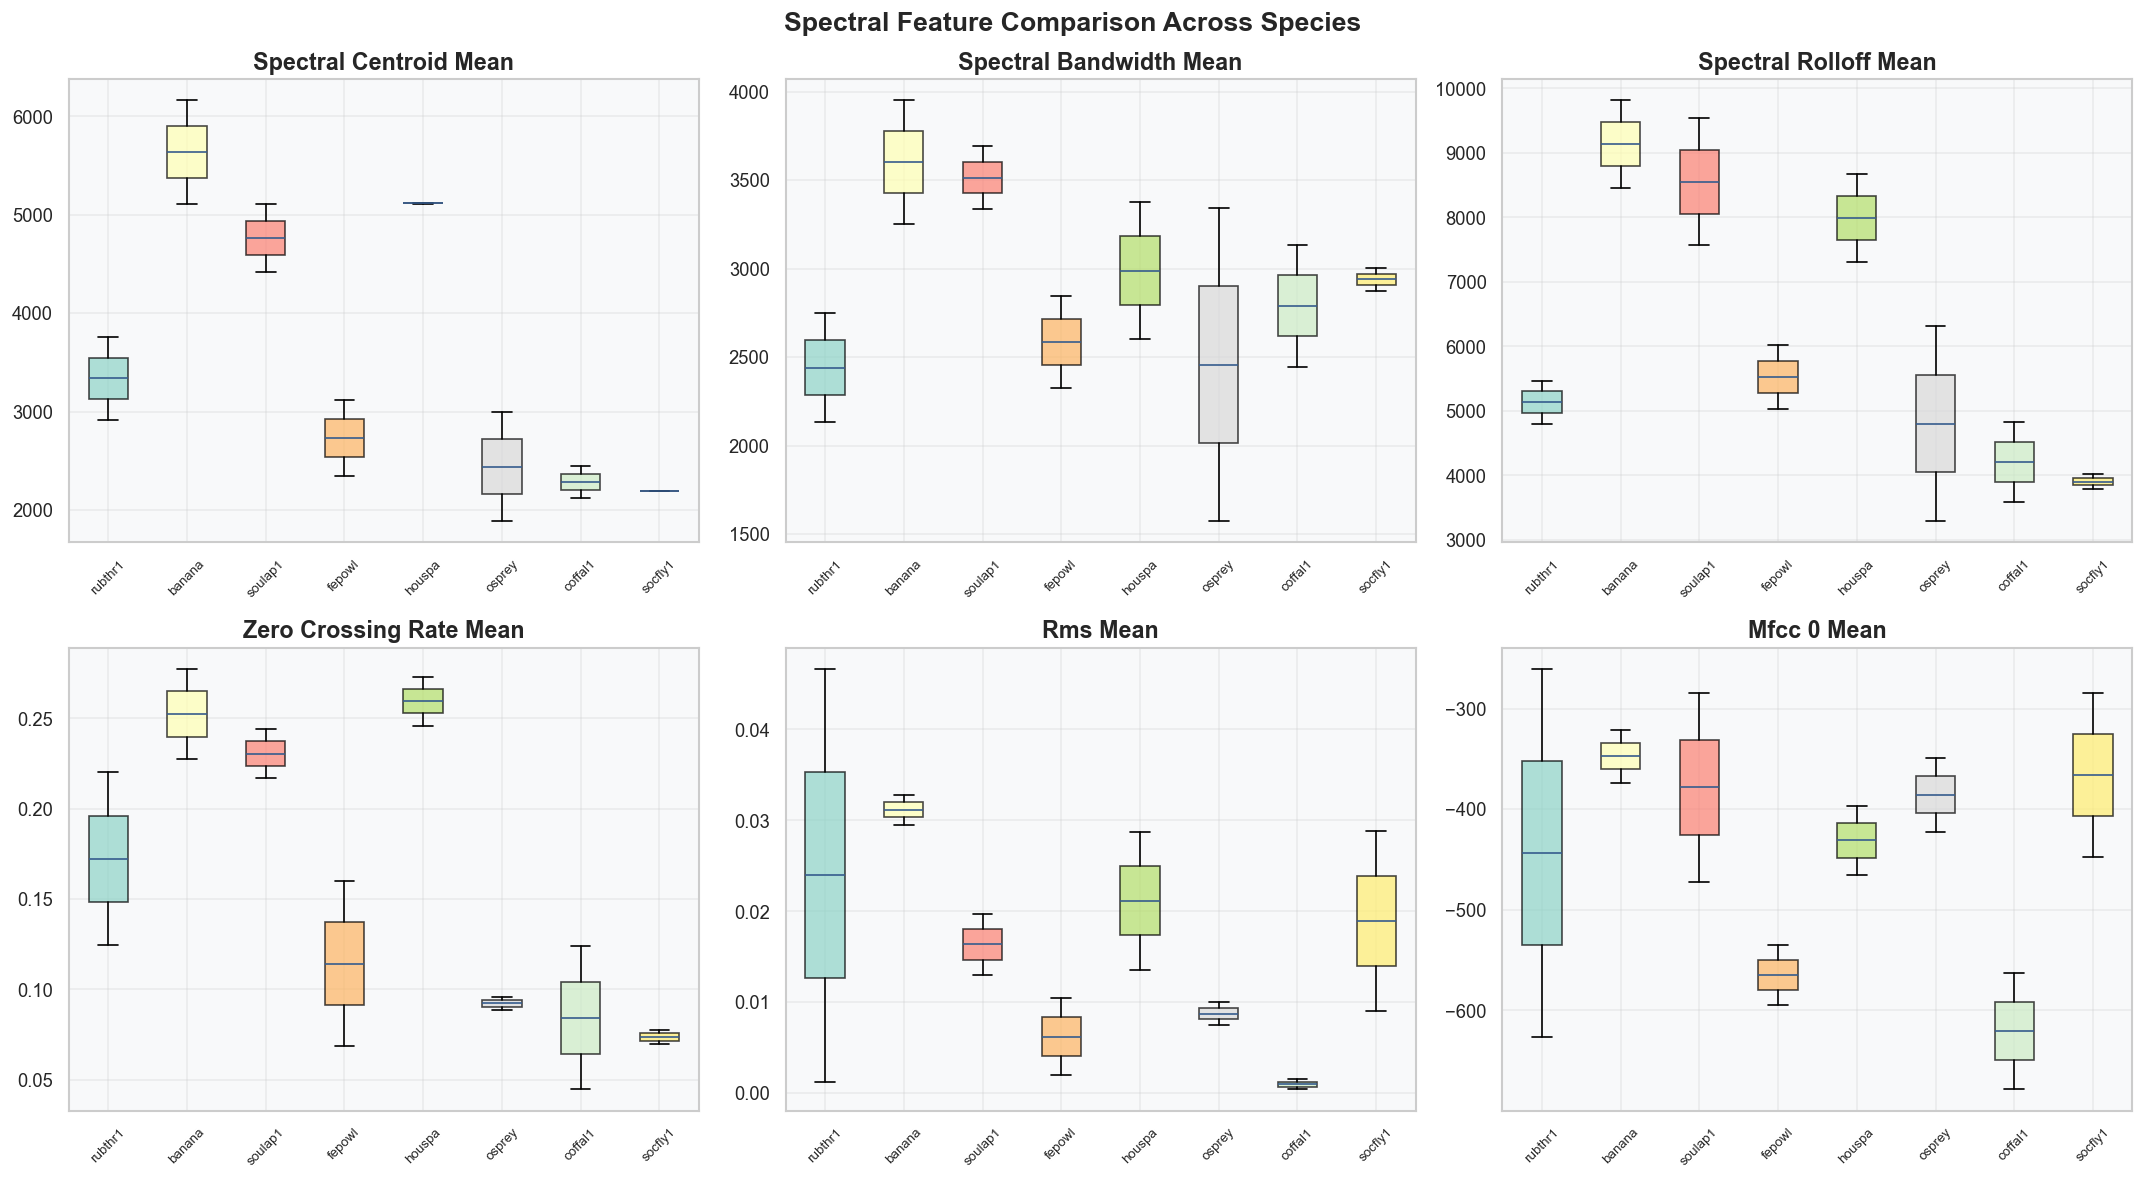

In [18]:
# =============================================================================
# Cell 12: Feature Distribution Comparison
# =============================================================================

# Compare top species on key spectral features
top_species = species_counts.index[:8]
feat_subset = features_df[features_df['species'].isin(top_species)]

key_features = ['spectral_centroid_mean', 'spectral_bandwidth_mean',
                'spectral_rolloff_mean', 'zero_crossing_rate_mean',
                'rms_mean', 'mfcc_0_mean']

if len(feat_subset) > 10:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, feat in enumerate(key_features):
        if feat in feat_subset.columns:
            data_to_plot = [
                feat_subset[feat_subset['species'] == sp][feat].dropna().values
                for sp in top_species if len(feat_subset[feat_subset['species'] == sp]) > 0
            ]
            valid_species = [
                sp for sp in top_species if len(feat_subset[feat_subset['species'] == sp]) > 0
            ]

            bp = axes[i].boxplot(data_to_plot, labels=valid_species,
                                 patch_artist=True, showfliers=False)
            colors = plt.cm.Set3(np.linspace(0, 1, len(valid_species)))
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            axes[i].set_title(feat.replace('_', ' ').title(), fontweight='bold')
            axes[i].tick_params(axis='x', rotation=45, labelsize=8)

    plt.suptitle("Spectral Feature Comparison Across Species",
                 fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('spectral_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()

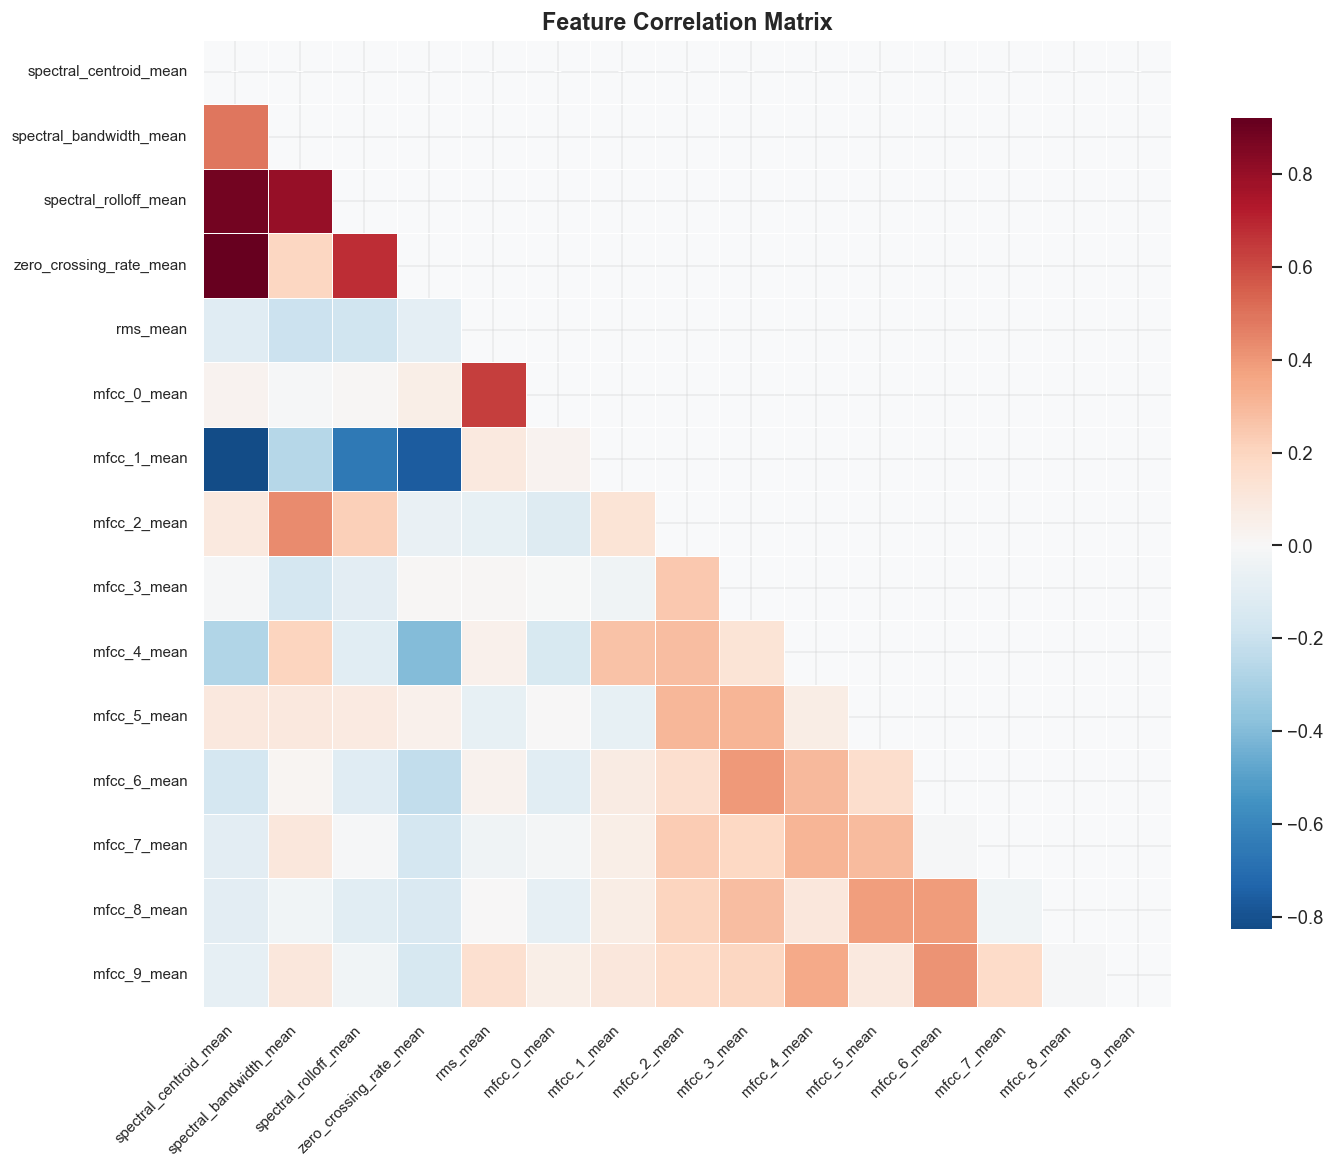

In [19]:
# =============================================================================
# Cell 13: Correlation Analysis of Features
# =============================================================================

numeric_features = features_df.select_dtypes(include=[np.number])

if len(numeric_features.columns) > 5:
    # Select key features for correlation
    corr_features = [c for c in numeric_features.columns if 'mean' in c][:15]
    corr_matrix = numeric_features[corr_features].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, ax=ax,
                square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8},
                annot_kws={'size': 8})
    ax.set_title("Feature Correlation Matrix", fontweight='bold', fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.savefig('feature_correlation.png', bbox_inches='tight', dpi=150)
    plt.show()

In [20]:
# =============================================================================
# Cell 14: t-SNE / PCA Visualization of Species Clusters
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Use only species with enough samples
species_sample_counts = feat_subset['species'].value_counts()
valid_species_tsne = species_sample_counts[species_sample_counts >= 3].index
tsne_data = feat_subset[feat_subset['species'].isin(valid_species_tsne)].copy()

if len(tsne_data) > 20:
    feature_cols = [c for c in tsne_data.columns if c != 'species']
    X = tsne_data[feature_cols].fillna(0).values
    y_labels = tsne_data['species'].values

    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)

    fig, ax = plt.subplots(figsize=(12, 8))
    unique_species = np.unique(y_labels)
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_species)))

    for sp, color in zip(unique_species, colors):
        mask = y_labels == sp
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                  c=[color], label=sp, s=40, alpha=0.7, edgecolors='white',
                  linewidths=0.5)

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.set_title("PCA of Spectral Features by Species", fontweight='bold')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9,
              frameon=True, ncol=1)
    plt.tight_layout()
    plt.savefig('pca_species.png', bbox_inches='tight', dpi=150)
    plt.show()

    print(f"\n📐 PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% (2 components)")

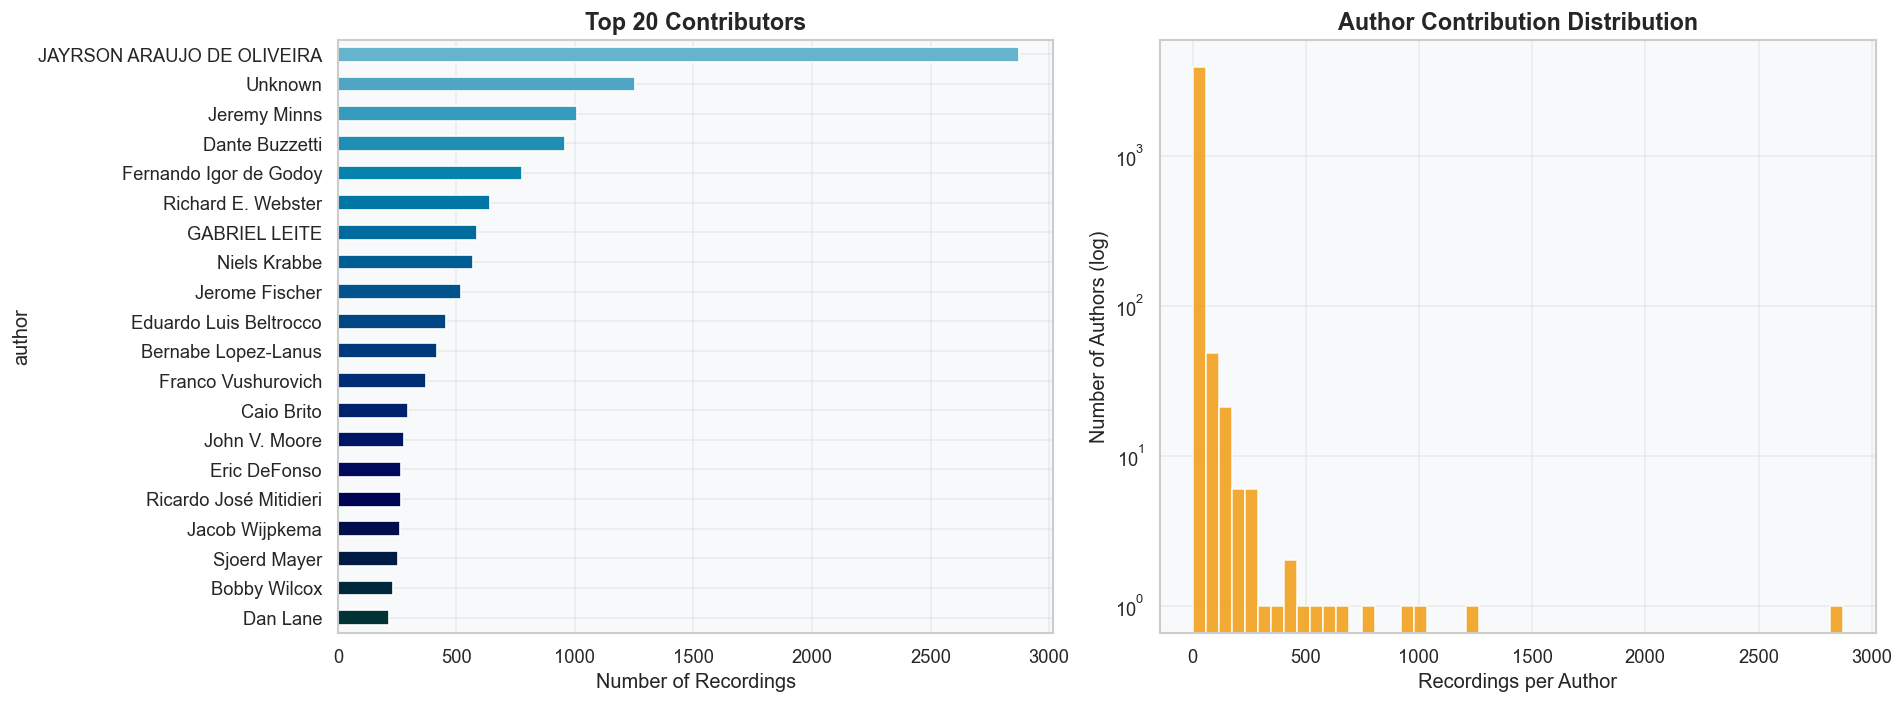


👥 Author Summary:
   Total unique authors: 4017
   Top contributor: JAYRSON ARAUJO DE OLIVEIRA (2874 recordings)
   Authors with 1 recording: 2227


In [21]:
# =============================================================================
# Cell 15: Author/Contributor Analysis
# =============================================================================

if 'author' in df.columns:
    author_counts = df['author'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Top contributors
    top_authors = author_counts.head(20)
    top_authors.sort_values().plot.barh(ax=axes[0],
                                         color=plt.cm.ocean(np.linspace(0.2, 0.8, len(top_authors))),
                                         edgecolor='white')
    axes[0].set_xlabel("Number of Recordings")
    axes[0].set_title("Top 20 Contributors", fontweight='bold')

    # Contributor distribution
    axes[1].hist(author_counts.values, bins=50, color='#f39c12', edgecolor='white',
                 alpha=0.85, log=True)
    axes[1].set_xlabel("Recordings per Author")
    axes[1].set_ylabel("Number of Authors (log)")
    axes[1].set_title("Author Contribution Distribution", fontweight='bold')

    plt.tight_layout()
    plt.savefig('author_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()

    print(f"\n👥 Author Summary:")
    print(f"   Total unique authors: {len(author_counts)}")
    print(f"   Top contributor: {author_counts.index[0]} ({author_counts.iloc[0]} recordings)")
    print(f"   Authors with 1 recording: {(author_counts == 1).sum()}")

🌍 Geographic columns found: ['latitude', 'longitude']
   latitude: range [-54.8574, 69.5780]
   longitude: range [-159.6556, 175.3239]


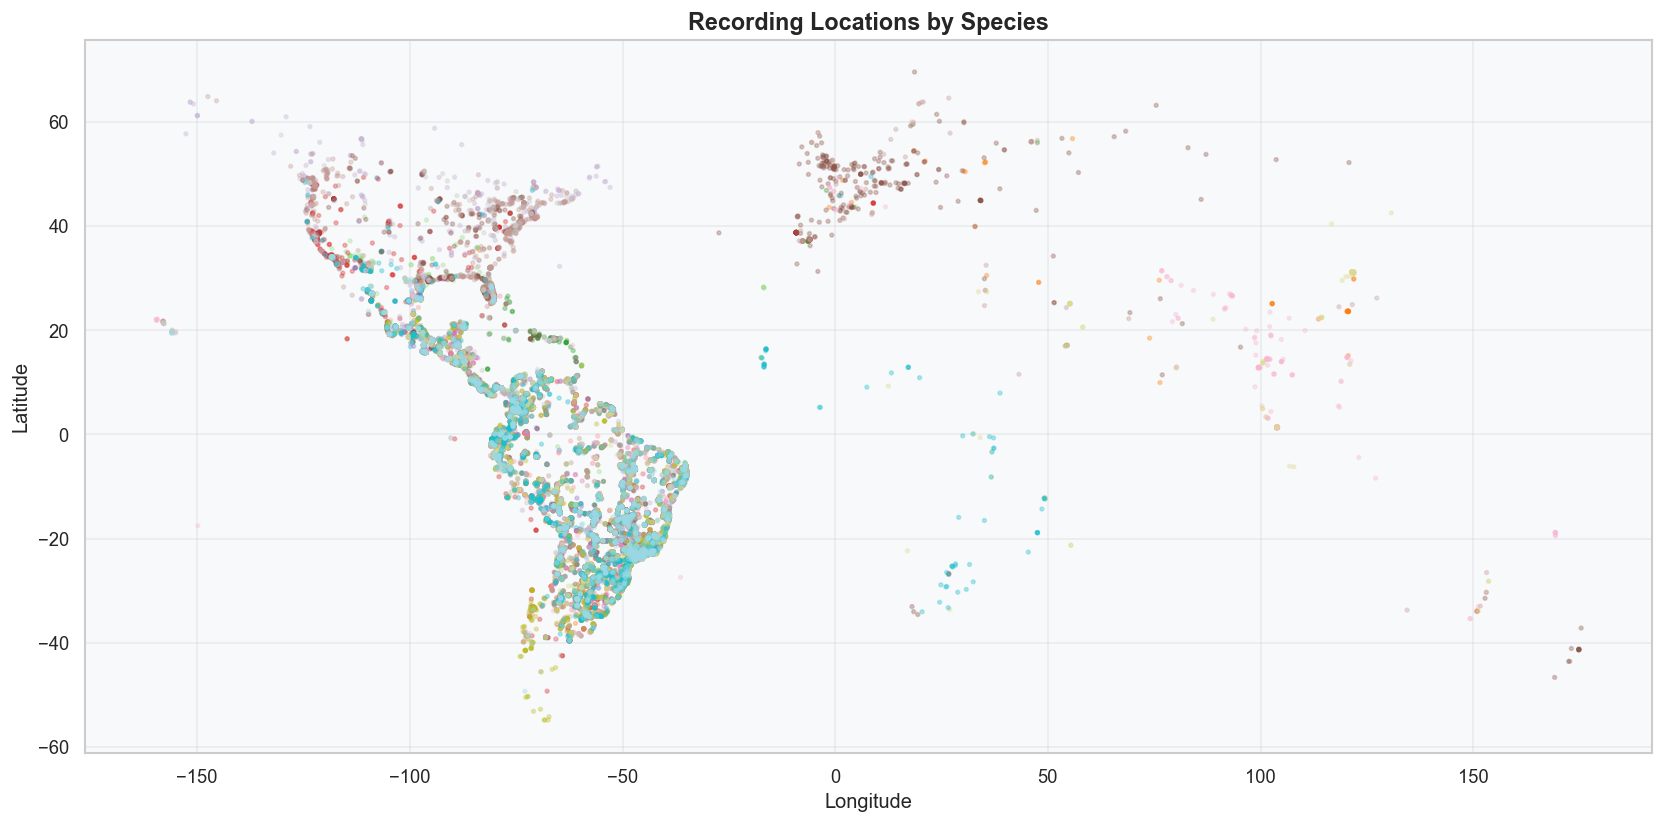


📋 All available columns: ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']


In [22]:
# =============================================================================
# Cell 16: Geographic / Temporal Analysis (if columns exist)
# =============================================================================

geo_cols = [c for c in df.columns if c in ['latitude', 'longitude', 'lat', 'lng',
                                             'country', 'location']]
time_cols = [c for c in df.columns if c in ['date', 'time', 'month', 'year',
                                              'recording_date']]

if geo_cols:
    print(f"🌍 Geographic columns found: {geo_cols}")
    for col in geo_cols:
        if df[col].dtype in ['float64', 'float32']:
            print(f"   {col}: range [{df[col].min():.4f}, {df[col].max():.4f}]")

    lat_col = next((c for c in geo_cols if 'lat' in c.lower()), None)
    lon_col = next((c for c in geo_cols if 'lon' in c.lower() or 'lng' in c.lower()), None)

    if lat_col and lon_col:
        valid_geo = df.dropna(subset=[lat_col, lon_col])
        if len(valid_geo) > 0:
            fig, ax = plt.subplots(figsize=(14, 7))
            scatter = ax.scatter(valid_geo[lon_col], valid_geo[lat_col],
                               c=valid_geo['primary_label'].astype('category').cat.codes,
                               cmap='tab20', s=5, alpha=0.3)
            ax.set_xlabel("Longitude")
            ax.set_ylabel("Latitude")
            ax.set_title("Recording Locations by Species", fontweight='bold')
            plt.tight_layout()
            plt.savefig('geo_distribution.png', bbox_inches='tight', dpi=150)
            plt.show()

if time_cols:
    print(f"📅 Temporal columns found: {time_cols}")

if not geo_cols and not time_cols:
    print("ℹ️ No geographic or temporal columns found in this dataset.")

# Print all available columns for reference
print(f"\n📋 All available columns: {list(df.columns)}")

In [24]:
# =============================================================================
# Cell 17: Summary Statistics & Recommendations
# =============================================================================

print("=" * 70)
print("📊 BIRDCLEF 2026 EDA SUMMARY")
print("=" * 70)

print(f"""
📁 Dataset Overview:
   • Total recordings: {len(df):,}
   • Unique species: {df['primary_label'].nunique()}
   • Features: {len(df.columns)} columns

⚖️ Class Balance:
   • Most common: {species_counts.idxmax()} ({species_counts.max():,} recordings)
   • Least common: {species_counts.idxmin()} ({species_counts.min()} recordings)
   • Imbalance ratio: {species_counts.max()/species_counts.min():.0f}x
   • Species with < 10 samples: {(species_counts < 10).sum()}

🔊 Audio Characteristics:
   • Mean duration: {valid_audio['duration'].mean():.1f}s
   • Median duration: {valid_audio['duration'].median():.1f}s
   • Duration range: [{valid_audio['duration'].min():.1f}s, {valid_audio['duration'].max():.1f}s]
   • Total audio: ~{valid_audio['duration'].sum()/3600:.0f} hours (sampled)
""")

if 'rating' in df.columns:
    print(f"""📈 Quality (Ratings):
   • Mean rating: {df['rating'].mean():.2f}
   • Median rating: {df['rating'].median():.2f}
   • High quality (≥4.0): {(df['rating'] >= 4.0).sum():,} ({(df['rating'] >= 4.0).mean()*100:.1f}%)
""")

print("""
💡 Modeling Recommendations:
   1. ADDRESS CLASS IMBALANCE: Use oversampling, weighted loss, or focal loss
   2. AUDIO PREPROCESSING: Standardize to fixed length (e.g., 5s chunks)
   3. DATA AUGMENTATION: Time shift, pitch shift, noise injection, mixup
   4. FEATURE EXTRACTION: Mel spectrograms (128 mel bands) work well for bird audio
   5. QUALITY FILTERING: Consider filtering low-rating recordings (< 3.0)
   6. SECONDARY LABELS: Use multi-label training to leverage secondary annotations
   7. ENSEMBLE: Combine CNN (spectrogram) + attention models for best results
""")

📊 BIRDCLEF 2026 EDA SUMMARY

📁 Dataset Overview:
   • Total recordings: 35,549
   • Unique species: 206
   • Features: 15 columns

⚖️ Class Balance:
   • Most common: rubthr1 (499 recordings)
   • Least common: 516975 (1 recordings)
   • Imbalance ratio: 499x
   • Species with < 10 samples: 25

🔊 Audio Characteristics:
   • Mean duration: 32.4s
   • Median duration: 21.7s
   • Duration range: [0.0s, 487.8s]
   • Total audio: ~16 hours (sampled)

📈 Quality (Ratings):
   • Mean rating: 2.60
   • Median rating: 3.50
   • High quality (≥4.0): 17,048 (48.0%)


💡 Modeling Recommendations:
   1. ADDRESS CLASS IMBALANCE: Use oversampling, weighted loss, or focal loss
   2. AUDIO PREPROCESSING: Standardize to fixed length (e.g., 5s chunks)
   3. DATA AUGMENTATION: Time shift, pitch shift, noise injection, mixup
   4. FEATURE EXTRACTION: Mel spectrograms (128 mel bands) work well for bird audio
   5. QUALITY FILTERING: Consider filtering low-rating recordings (< 3.0)
   6. SECONDARY LABELS: Use 